# Domain A: Transcriptomic Identity and Neural Coding

This notebook addresses three questions:
- **A1:** Do transcriptomically defined cell types have distinct tuning properties?
- **A2:** Does gene expression predict functional response properties at the single-cell level?
- **A3:** How does transcriptomic identity shape population coding geometry?

**Data:** Zarr multimodal stores with ΔF/F calcium traces (X matrix, cells × trials), stimulus metadata (var), cell-type labels & gene expression (obs).

In [2]:
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace
from scipy.optimize import curve_fit
from scipy.stats import kruskal, mannwhitneyu, spearmanr, pearsonr
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA, NMF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from pathlib import Path    
import warnings
warnings.filterwarnings('ignore')

sns.set_context('talk')
sns.set_style('whitegrid')

# ══════════════════════════════════════════════════════════════════════
# Load data from zarr multimodal stores
# ══════════════════════════════════════════════════════════════════════
ZARR_DIR = Path('multimodal_data')
MOUSE_IDS = [f.stem.split('_')[0] for f in ZARR_DIR.glob('*_multimodal_data.zarr')]
SESSIONS = ['session_1', 'session_2', 'session_3']
session_type = ['drifting_gratings']




In [3]:
def zarr_to_df(zarr_group):
    """Convert a zarr group to a pandas DataFrame, handling string types."""
    return pd.DataFrame({
        key: zarr_group[key][:].astype(str) if zarr_group[key][:].dtype.kind in {'S', 'O'} else zarr_group[key][:]
        for key in zarr_group.keys()
    })


def load_mouse_zarr(mouse_id):
    """Load one mouse's data from zarr, returning an adata-like SimpleNamespace."""
    z = zarr.open(str(ZARR_DIR / f'{mouse_id}_multimodal_data.zarr'), mode='r')
    
    # ── Cell metadata (obs) ──
    ct = z['transcriptomics/cell_type']
    morph = z['morphology/mask_properties']
    obs_dict = {
        'unique_id': z['unique_id'][:],
        'mouse_id': mouse_id,
        'class_name': ct['class_name'][:],
        'class_label': ct['class_label'][:],
        'class_bootstrapping_probability': ct['class_bootstrapping_probability'][:],
        'subclass_name': ct['subclass_name'][:],
        'subclass_label': ct['subclass_label'][:],
        'subclass_bootstrapping_probability': ct['subclass_bootstrapping_probability'][:],
        'supertype_name': ct['supertype_name'][:],
        'supertype_label': ct['supertype_label'][:],
        'supertype_bootstrapping_probability': ct['supertype_bootstrapping_probability'][:],
        'cluster_name': ct['cluster_name'][:],
        'cluster_label': ct['cluster_label'][:],
        'cluster_alias': ct['cluster_alias'][:],
        'cluster_bootstrapping_probability': ct['cluster_bootstrapping_probability'][:],
        'x_loc': morph['centroid_x_um'][:],
        'y_loc': morph['centroid_y_um'][:],
        'z_loc': morph['centroid_z_um'][:],
    }
    # Gene expression
    gene_names = sorted(z['transcriptomics/cellxgene'].keys())
    for g in gene_names:
        obs_dict[g] = z[f'transcriptomics/cellxgene/{g}'][:]
    obs_df = pd.DataFrame(obs_dict)
    n_cells = len(obs_df)
    
    # ── Trial-averaged responses across all sessions ──
    X_sessions, var_sessions = [], []
    for si, sess in enumerate(SESSIONS):
        gs = z[f'ophys/drifting_gratings/{sess}/stim_aligned_dff/GratingStim']
        dff = gs['dff'][:]               # (2186, 41, n_cells)
        time_rel = gs['time_relative'][:]
        running = gs['running'][:]       # (2186, 41, 2)
        
        # Trial metadata
        gray = gs['trial_info/gray_screen'][:]
        valid = ~gray  # non-grey-screen grating trials
        
        # Trial-averaged ΔF/F (stimulus window: 0 to 2 s)
        stim_mask = (time_rel >= 0) & (time_rel <= 2.0)
        dff_avg = dff[valid][:, stim_mask, :].mean(axis=1)  # (n_valid, n_cells)
        
        # Running (average over stimulus window)
        run_speed = running[valid][:, stim_mask, 0].mean(axis=1)
        
        X_sessions.append(dff_avg.T)  # (n_cells, n_valid)
        var_sessions.append(pd.DataFrame({
            'contrast': gs['trial_info/contrast'][:][valid],
            'orientation': gs['trial_info/orientation'][:][valid],
            'temporal_frequency': gs['trial_info/temporal_frequency'][:][valid],
            'spatial_frequency': gs['trial_info/spatial_frequency'][:][valid],
            'stim_block': gs['trial_info/stim_block'][:][valid],
            'stim_name': gs['trial_info/stim_name'][:][valid],
            'start_time': gs['trial_info/start_time'][:][valid],
            'stop_time': gs['trial_info/stop_time'][:][valid],
            'duration': gs['trial_info/duration'][:][valid],
            'avg_running': run_speed,
            'is_running': run_speed > 1.0,
            'day': si + 1,
        }))
    
    X_mouse = np.hstack(X_sessions)  # (n_cells, total_trials)
    var_mouse = pd.concat(var_sessions, ignore_index=True)
    
    return SimpleNamespace(
        X=X_mouse, obs=obs_df, var=var_mouse,
        n_obs=n_cells, n_vars=var_mouse.shape[0]
    )

# ── Load all mice ──
adata_list = [load_mouse_zarr(mid) for mid in MOUSE_IDS]

# ── Concatenated form ──
obs = pd.concat([a.obs for a in adata_list], ignore_index=True)
X = np.vstack([a.X for a in adata_list])      # (total_cells, trials_per_mouse)
var = adata_list[0].var.copy()                 # stimulus params same for all mice

# ── Identify gene expression columns ──
META_COLS = {'unique_id', 'mouse_id', 'class_name', 'class_label',
             'class_bootstrapping_probability', 'subclass_name', 'subclass_label',
             'subclass_bootstrapping_probability', 'supertype_name', 'supertype_label',
             'supertype_bootstrapping_probability', 'cluster_name', 'cluster_label',
             'cluster_alias', 'cluster_bootstrapping_probability',
             'x_loc', 'y_loc', 'z_loc'}
GENE_COLS = [c for c in obs.columns if c not in META_COLS]
print(f"Gene expression columns: {len(GENE_COLS)}")

# ── Color palette for subclasses ──
SUBCLASS_ORDER = ['007 L2/3 IT CTX Glut', '006 L4/5 IT CTX Glut', '022 L5 ET CTX Glut',
                  '052 Pvalb Gaba', '053 Sst Gaba', '046 Vip Gaba', '049 Lamp5 Gaba']
SUBCLASS_COLORS = {'007 L2/3 IT CTX Glut': '#1f77b4', '006 L4/5 IT CTX Glut': '#2ca02c',
                   '022 L5 ET CTX Glut': '#9467bd', '052 Pvalb Gaba': '#d62728',
                   '053 Sst Gaba': '#ff7f0e', '046 Vip Gaba': '#e377c2', '049 Lamp5 Gaba': '#8c564b'}
SUBCLASS_SHORT = {'007 L2/3 IT CTX Glut': 'L2/3 IT', '006 L4/5 IT CTX Glut': 'L4/5 IT',
                  '022 L5 ET CTX Glut': 'L5 ET', '052 Pvalb Gaba': 'Pvalb',
                  '053 Sst Gaba': 'Sst', '046 Vip Gaba': 'Vip', '049 Lamp5 Gaba': 'Lamp5'}
present_subclasses = [s for s in SUBCLASS_ORDER if s in obs['subclass_name'].unique()]

# Backward-compatible adata object for downstream cells
adata = SimpleNamespace(X=X, obs=obs, var=var, n_obs=len(obs), n_vars=X.shape[1])

orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
tfs = np.array([1, 2, 4, 8, 15])

print(f"Total cells: {len(obs)}, Trials per mouse: {X.shape[1]}")
print(f"Subclasses: {obs['subclass_name'].value_counts().to_dict()}")

Gene expression columns: 299
Total cells: 2824, Trials per mouse: 3279
Subclasses: {'006 L4/5 IT CTX Glut': 1360, '007 L2/3 IT CTX Glut': 1168, '052 Pvalb Gaba': 120, '046 Vip Gaba': 75, '053 Sst Gaba': 56, '022 L5 ET CTX Glut': 23, '049 Lamp5 Gaba': 22}


## A1: Cell-Type-Specific Tuning Properties

Load precomputed tuning properties from zarr stores (computed in `Compute_Tuning_Properties.ipynb`) and compare across transcriptomic subclasses.

In [5]:
# ══════════════════════════════════════════════════════════════════════
# A1.1  Compute trial-averaged responses per stimulus condition per cell
# ══════════════════════════════════════════════════════════════════════
ori_responses_list = []
crf_responses_list = []
tf_responses_list = []

for adata in adata_list:
    X = adata.X  # cells x trials
    var = adata.var.copy()
    # obs = adata.obs.copy()


    orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
    contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
    tfs = np.array([1, 2, 4, 8, 15])

    # ── Orientation tuning (use contrast-context blocks 0,2 where TF=1 Hz) ──
    ori_mask_blocks = var['stim_block'].isin([0.0, 2.0])
    ori_responses = np.zeros((adata.n_obs, len(orientations)))
    for i, ori in enumerate(orientations):
        mask = ori_mask_blocks & (var['orientation'] == ori)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            ori_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)

    # ── Contrast response function (contrast-context blocks 0,2; collapse orientations) ──
    crf_responses = np.zeros((adata.n_obs, len(contrasts)))
    for i, c in enumerate(contrasts):
        mask = ori_mask_blocks & (var['contrast'] == c)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            crf_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)

    # ── Temporal frequency tuning (speed-context blocks 1,3; contrast=0.8) ──
    tf_mask_blocks = var['stim_block'].isin([1.0, 3.0])
    tf_responses = np.zeros((adata.n_obs, len(tfs)))
    for i, tf in enumerate(tfs):
        mask = tf_mask_blocks & (var['temporal_frequency'] == tf)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            tf_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)



    ori_responses_list.append(ori_responses)
    crf_responses_list.append(crf_responses)
    tf_responses_list.append(tf_responses)

ori_responses_all = np.concatenate(ori_responses_list, axis=0)
crf_responses_all = np.concatenate(crf_responses_list, axis=0)
tf_responses_all = np.concatenate(tf_responses_list, axis=0)

print(f"Orientation responses: {ori_responses_all.shape}")
print(f"CRF responses: {crf_responses_all.shape}")
print(f"TF responses: {tf_responses_all.shape}")

Orientation responses: (2824, 8)
CRF responses: (2824, 5)
TF responses: (2824, 5)


In [6]:
# ══════════════════════════════════════════════════════════════════════
# A1.2  Load precomputed tuning metrics from zarr
# ══════════════════════════════════════════════════════════════════════

TUNING_COLS = ['OSI', 'DSI', 'pref_ori', 'max_response', 'mean_response',
               'bandwidth', 'C50', 'Rmax_crf', 'n_exponent', 'pref_TF',
               'TF_max_response', 'TF_lowpass_idx']

tuning_dfs = []
for mouse_id in MOUSE_IDS:
    z = zarr.open(str(ZARR_DIR / f'{mouse_id}_multimodal_data.zarr'), mode='r')
    # Average tuning properties across sessions
    session_dfs = []
    for sess in SESSIONS:
        tp = z[f'ophys/drifting_gratings/{sess}/tuning_properties']
        session_dfs.append(pd.DataFrame({col: tp[col][:] for col in TUNING_COLS}))
    # Mean across sessions
    mouse_tuning = pd.concat(session_dfs).groupby(level=0).mean()
    mouse_tuning['mouse_id'] = mouse_id
    tuning_dfs.append(mouse_tuning)

tuning_df = pd.concat(tuning_dfs, ignore_index=True)
tuning_df['subclass'] = obs['subclass_name'].values
tuning_df['supertype'] = obs['supertype_name'].values
tuning_df['cluster'] = obs['cluster_name'].values
tuning_df['unique_id'] = obs['unique_id'].values

n_cells = len(tuning_df)
print(f"Loaded tuning properties for {n_cells} cells from zarr")
print(tuning_df[TUNING_COLS].describe())

Loaded tuning properties for 2824 cells from zarr
               OSI          DSI     pref_ori  max_response  mean_response  \
count  2824.000000  2824.000000  2824.000000   2824.000000    2824.000000   
mean      0.092522     0.081359    91.538757      0.092574       0.065708   
std       0.057737     0.046377    31.930695      0.069364       0.049025   
min       0.015089     0.007720     5.620370      0.004403       0.001863   
25%       0.056084     0.051253    67.869325      0.044977       0.032151   
50%       0.075165     0.069797    93.417012      0.075383       0.053521   
75%       0.108385     0.096816   115.383426      0.119770       0.085338   
max       0.404326     0.310649   173.130460      0.650753       0.444806   

         bandwidth          C50      Rmax_crf   n_exponent      pref_TF  \
count  2691.000000  2616.000000  2.616000e+03  2616.000000  2824.000000   
mean     52.539934     0.484395  1.230085e-01     4.818599     4.830382   
std      22.225813     0.287892

In [32]:
# ══════════════════════════════════════════════════════════════════════
# A1.5  Extract pre-computed GLM coefficients from zarr and add to tuning_df
# ══════════════════════════════════════════════════════════════════════

glm_coef_cols = []

for mouse_id in MOUSE_IDS:
    z = zarr.open(str(ZARR_DIR / f'{mouse_id}_multimodal_data.zarr'), mode='r')
    
    # Get cell indices for this mouse
    mouse_mask = obs['mouse_id'] == mouse_id
    mouse_start_idx = obs.index[mouse_mask].min()
    mouse_end_idx = obs.index[mouse_mask].max()
    # print(f"Processing mouse {mouse_id}: cells {mouse_start_idx} to {mouse_end_idx} ({mouse_end_idx - mouse_start_idx + 1} cells)")
    # Average GLM coefficients across sessions
    session_glm_list = []
    for sess in SESSIONS:
        glm_group = z[f'ophys/drifting_gratings/{sess}/glm/coef']
        
        # Extract all GLM coefficient datasets
        glm_coef_cols = [k for k in glm_group.keys() if k.startswith('glm-coef_contrast_') and k.endswith('_direction_pref_0')]
        glm_coef_cols = glm_coef_cols + [k for k in glm_group.keys() if k.startswith('glm-coef_TF_') and k.endswith('_direction_pref_0')]
        session_glm_dict = {k: glm_group[k][:] for k in glm_coef_cols}
        session_glm_list.append(session_glm_dict)
    
    # Concatenate and average across sessions
    n_cells_mouse = obs.loc[mouse_mask].shape[0]
    print(f"Mouse {mouse_id}: averaging GLM coefficients for {n_cells_mouse} cells across {len(session_glm_list)} sessions")
    for coef_name in glm_coef_cols:
        coef_avg = np.nanmean(
            np.array([s[coef_name] for s in session_glm_list if coef_name in s]),
            axis=0
        )
        print(f"Mouse {mouse_id}, Coef {coef_name}: avg shape {coef_avg.shape}, expected {n_cells_mouse}")
        if len(coef_avg) == n_cells_mouse:
            if coef_avg.shape[1] == 1:
                tuning_df.loc[mouse_mask, coef_name] = coef_avg[:, 0]
            else:
                pca_ = PCA(n_components=2)  # limit to 2 components for simplicity
                coef_avg = pca_.fit_transform(coef_avg)
                if np.sum(np.isnan(coef_avg)) > 0:
                    warnings.warn(f"NaN values found in averaged coefficients for {coef_name} in mouse {mouse_id}")
                for j in range(coef_avg.shape[1]):
                    # print(np.sum(coef_avg[:, j]))
                    tuning_df.loc[mouse_mask, f"{coef_name}_pc{j}"] = coef_avg[:, j]
        
print(f"Extracted {len(glm_coef_cols)} GLM coefficient columns from zarr")
print(f"GLM columns: {glm_coef_cols[:5]}... (showing first 5)")
print(f"tuning_df shape: {tuning_df.shape}")


Mouse 786297: averaging GLM coefficients for 1173 cells across 3 sessions
Mouse 786297, Coef glm-coef_contrast_0.05_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_contrast_0.1_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_contrast_0.2_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_contrast_0.4_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_contrast_0.8_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_TF_15_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_TF_1_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_TF_2_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_TF_4_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 786297, Coef glm-coef_TF_8_direction_pref_0: avg shape (1173, 30), expected 1173
Mouse 797371: 

In [24]:
tuning_df


,OSI,DSI,pref_ori,max_response,mean_response,bandwidth,C50,Rmax_crf,n_exponent,pref_TF,...,glm-coef_TF_15_direction_pref_0_pc0,glm-coef_TF_15_direction_pref_0_pc1,glm-coef_TF_1_direction_pref_0_pc0,glm-coef_TF_1_direction_pref_0_pc1,glm-coef_TF_2_direction_pref_0_pc0,glm-coef_TF_2_direction_pref_0_pc1,glm-coef_TF_4_direction_pref_0_pc0,glm-coef_TF_4_direction_pref_0_pc1,glm-coef_TF_8_direction_pref_0_pc0,glm-coef_TF_8_direction_pref_0_pc1
0,0.073766,0.133105,60.567957,0.031858,0.022989,25.978589,0.742111,2.601438e-13,0.100007,5.666667,...,-0.144330,0.008223,-0.323241,-0.006082,-0.522679,0.003900,-0.447576,0.012686,-0.229002,-0.002994
1,0.072703,0.070375,28.561558,0.087122,0.061132,36.228326,0.516116,2.053176e-02,1.467502,1.333333,...,-0.128720,0.006403,-0.317193,-0.008222,-0.511822,-0.001475,-0.451295,0.006854,-0.214707,0.002156
2,0.099121,0.065309,47.812632,0.043210,0.032155,67.404612,0.458320,3.123766e-02,1.538889,1.000000,...,-0.165896,0.000991,-0.267128,-0.005412,-0.424934,-0.023618,-0.450125,0.010038,-0.248523,0.001319
3,0.096412,0.089171,61.665217,0.079723,0.056025,22.339878,0.766713,2.831532e-03,3.397071,1.000000,...,-0.146389,0.004756,-0.331514,-0.008257,-0.530115,0.004046,-0.448036,0.016664,-0.216176,-0.000050
4,0.055579,0.070381,120.347878,0.067099,0.051924,44.753252,0.999834,6.778211e-02,5.036631,1.000000,...,-0.101380,0.043629,0.579463,0.241012,1.267864,0.619436,0.127439,0.447223,0.171576,-0.183572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,0.098534,0.133486,58.501498,0.050696,0.033403,66.531775,0.605700,4.048658e-02,4.161939,4.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2820,0.107533,0.070695,116.274009,0.063464,0.046026,90.000000,0.181459,9.926698e-03,6.698417,3.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2821,0.160570,0.175256,82.217806,0.108928,0.054436,56.507316,0.491007,3.375892e-01,6.699999,1.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2822,0.188119,0.163978,69.091268,0.119269,0.055232,60.209570,0.514175,2.265256e-01,5.050000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== Kruskal-Wallis H-test across subclasses ===
  OSI                 : H=    5.50, p=4.81e-01 ns
  DSI                 : H=    3.89, p=6.91e-01 ns
  C50                 : H=    8.25, p=2.20e-01 ns
  Rmax_crf            : H=   19.21, p=3.83e-03 **
  pref_TF             : H=   28.10, p=9.00e-05 ***
  TF_lowpass_idx      : H=   28.89, p=6.38e-05 ***
  bandwidth           : H=    6.11, p=4.11e-01 ns
  max_response        : H=   39.29, p=6.27e-07 ***


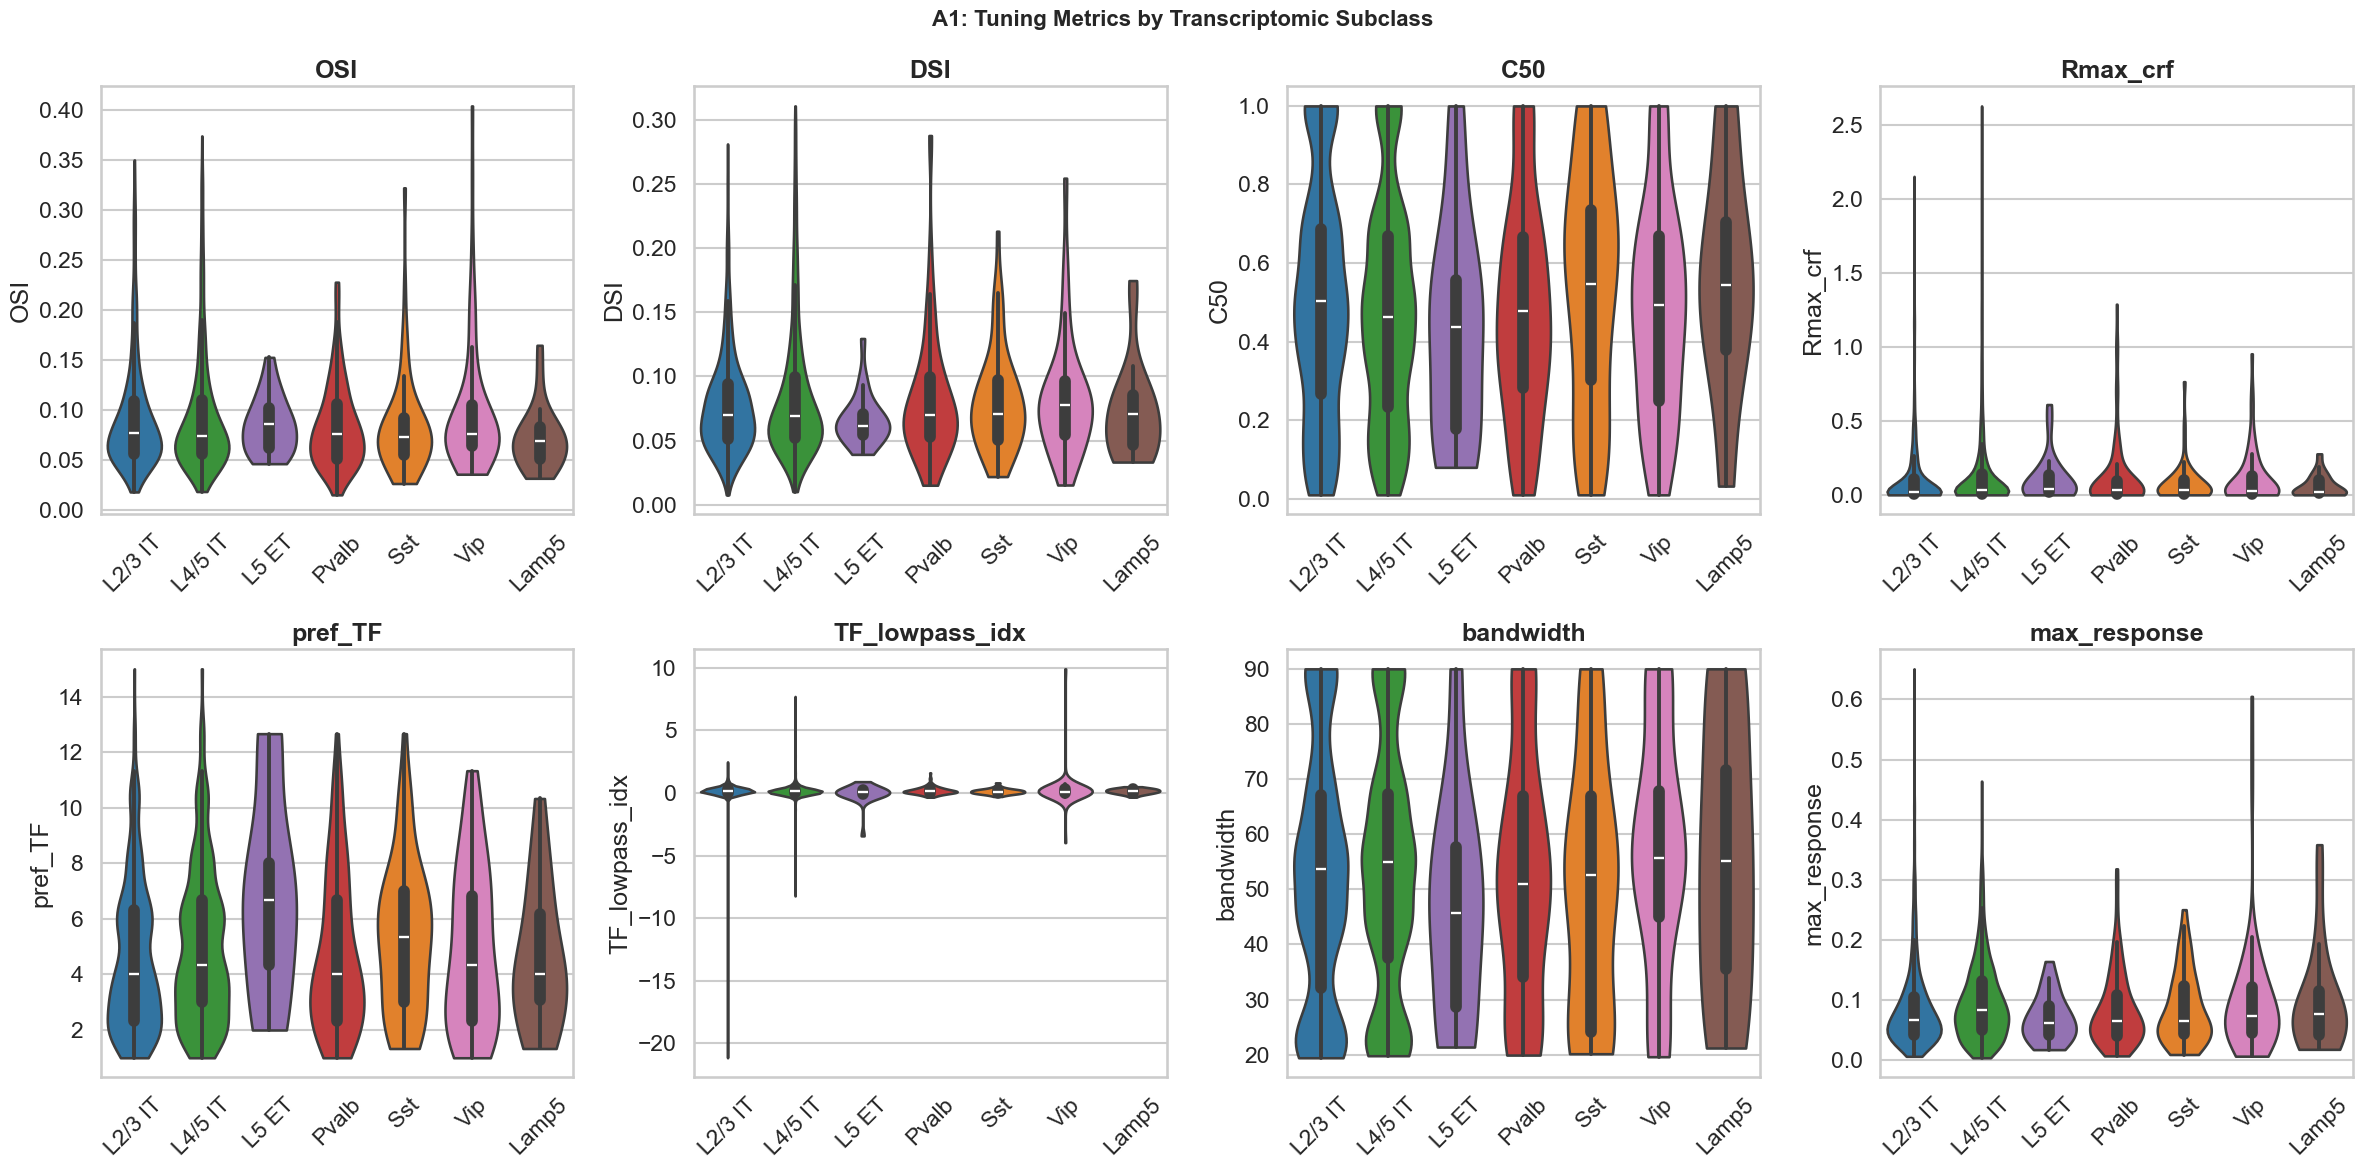

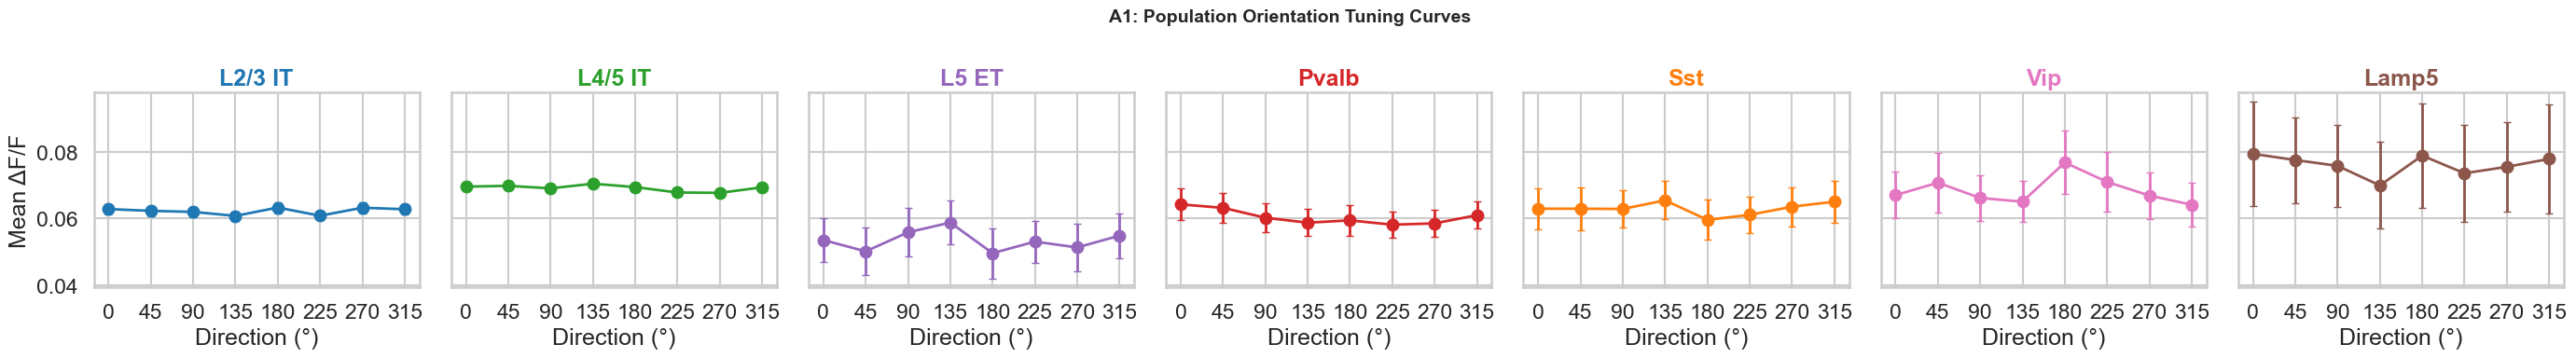

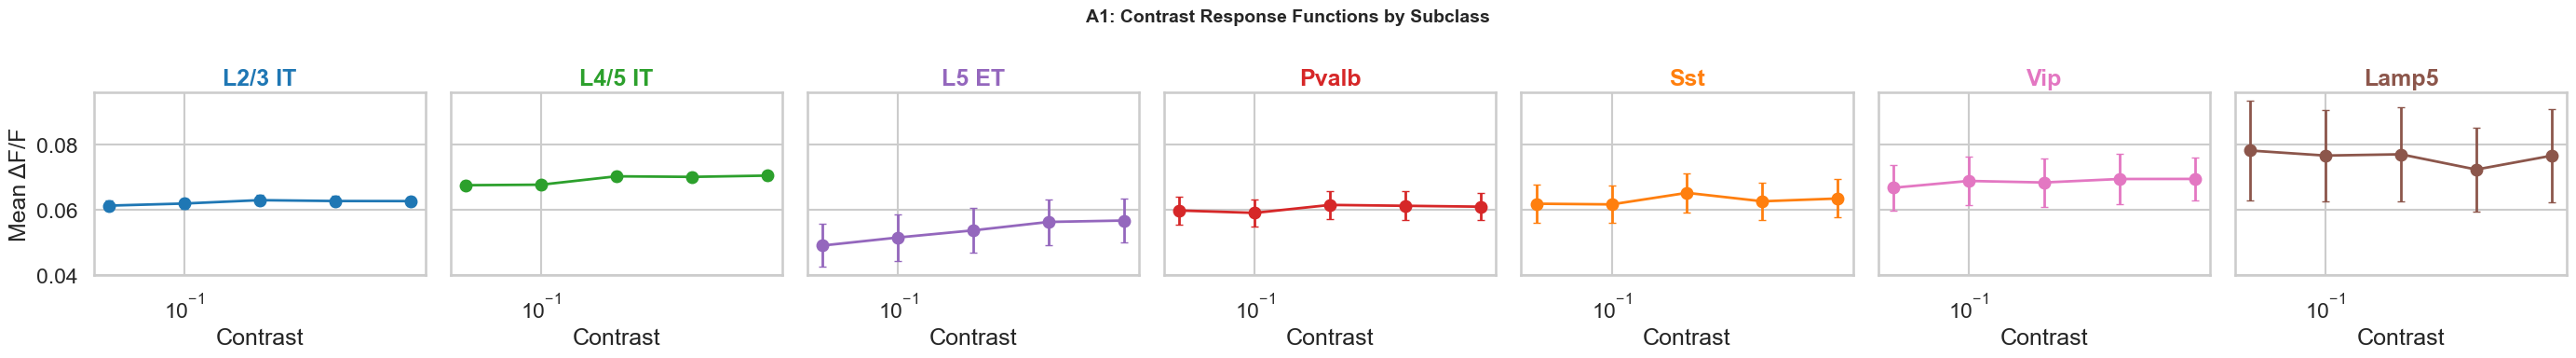

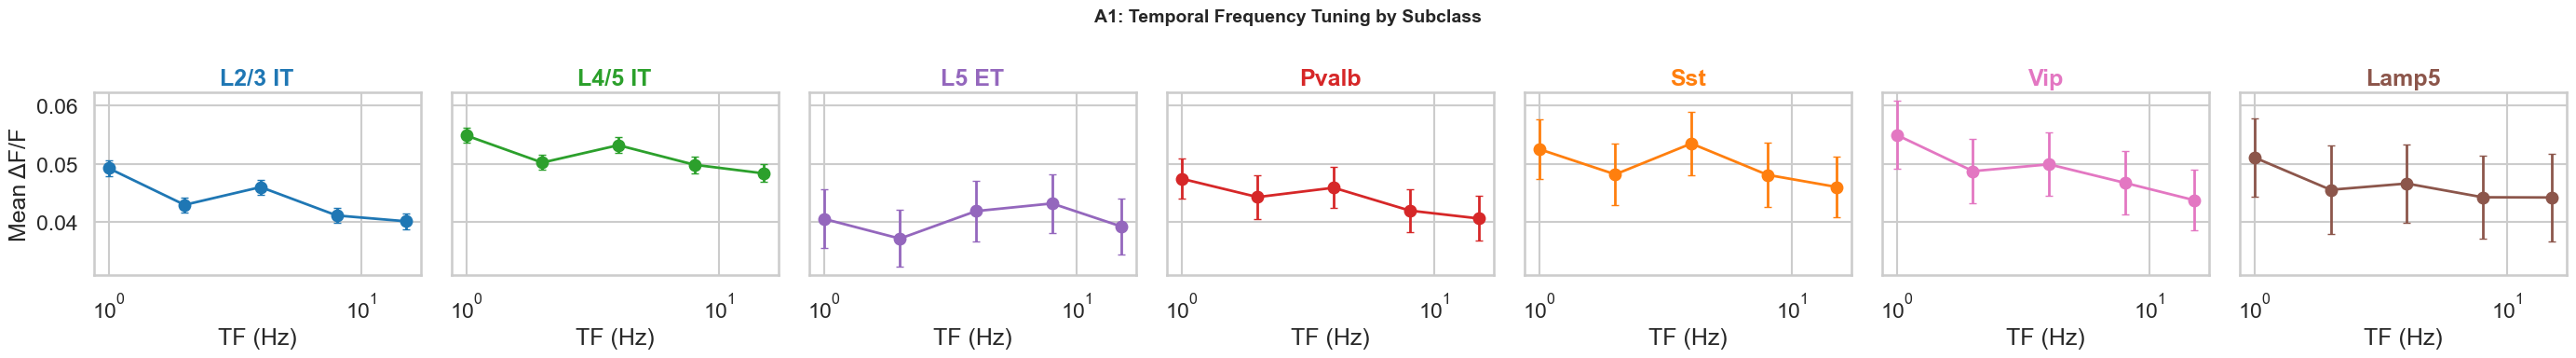

In [31]:
# ══════════════════════════════════════════════════════════════════════
# A1.3a  Compare tuning parameters across subclasses (stats + visualization)
# ══════════════════════════════════════════════════════════════════════

metrics = ['OSI', 'DSI', 'C50', 'Rmax_crf', 'pref_TF', 'TF_lowpass_idx', 'bandwidth', 'max_response']
present_subclasses = [s for s in SUBCLASS_ORDER if s in tuning_df['subclass'].unique()]

# ── Kruskal-Wallis tests ──
print("=== Kruskal-Wallis H-test across subclasses ===")
for met in metrics:
    groups = [tuning_df.loc[tuning_df['subclass'] == s, met].dropna().values for s in present_subclasses]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"  {met:20s}: H={stat:8.2f}, p={p:.2e} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

# ── Visualization: Violin plots of tuning metrics by subclass ──
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
for ax, met in zip(axes.flat, metrics):
    data_plot = tuning_df[tuning_df['subclass'].isin(present_subclasses)].copy()
    data_plot['subclass_short'] = data_plot['subclass'].map(SUBCLASS_SHORT)
    short_order = [SUBCLASS_SHORT[s] for s in present_subclasses]
    short_colors = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}
    sns.violinplot(data=data_plot, x='subclass_short', y=met, order=short_order,
                   palette=short_colors, cut=0, inner='box', ax=ax)
    ax.set_title(met, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('A1: Tuning Metrics by Transcriptomic Subclass', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population orientation tuning curves per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = ori_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(orientations, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('Direction (°)')
    ax.set_xticks(orientations)
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Population Orientation Tuning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population CRF per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = crf_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(contrasts, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_xscale('log')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('Contrast')
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Contrast Response Functions by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population TF tuning per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = tf_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(tfs, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_xscale('log')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('TF (Hz)')
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Temporal Frequency Tuning by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Kruskal-Wallis: supertype within subclass ===
  Sst      | C50           : H=    1.50, p=2.20e-01, groups=2 ns
  L2/3 IT  | C50           : H=    2.16, p=3.39e-01, groups=3 ns
  Vip      | C50           : H=    0.31, p=5.79e-01, groups=2 ns
  L4/5 IT  | C50           : H=    0.95, p=8.13e-01, groups=4 ns
  L4/5 IT  | DSI           : H=   13.64, p=3.43e-03, groups=4 **
  L2/3 IT  | DSI           : H=    6.17, p=4.58e-02, groups=3 *
  Vip      | DSI           : H=    0.19, p=6.60e-01, groups=2 ns
  Sst      | DSI           : H=    0.10, p=7.49e-01, groups=2 ns
  L4/5 IT  | OSI           : H=   18.11, p=4.18e-04, groups=4 ***
  L2/3 IT  | OSI           : H=   10.02, p=6.66e-03, groups=3 **
  Vip      | OSI           : H=    1.68, p=1.95e-01, groups=2 ns
  Sst      | OSI           : H=    1.34, p=2.47e-01, groups=2 ns
  L4/5 IT  | Rmax_crf      : H=    3.97, p=2.65e-01, groups=4 ns
  Sst      | Rmax_crf      : H=    0.63, p=4.26e-01, groups=2 ns
  L2/3 IT  | Rmax_crf      : H=    1.68,

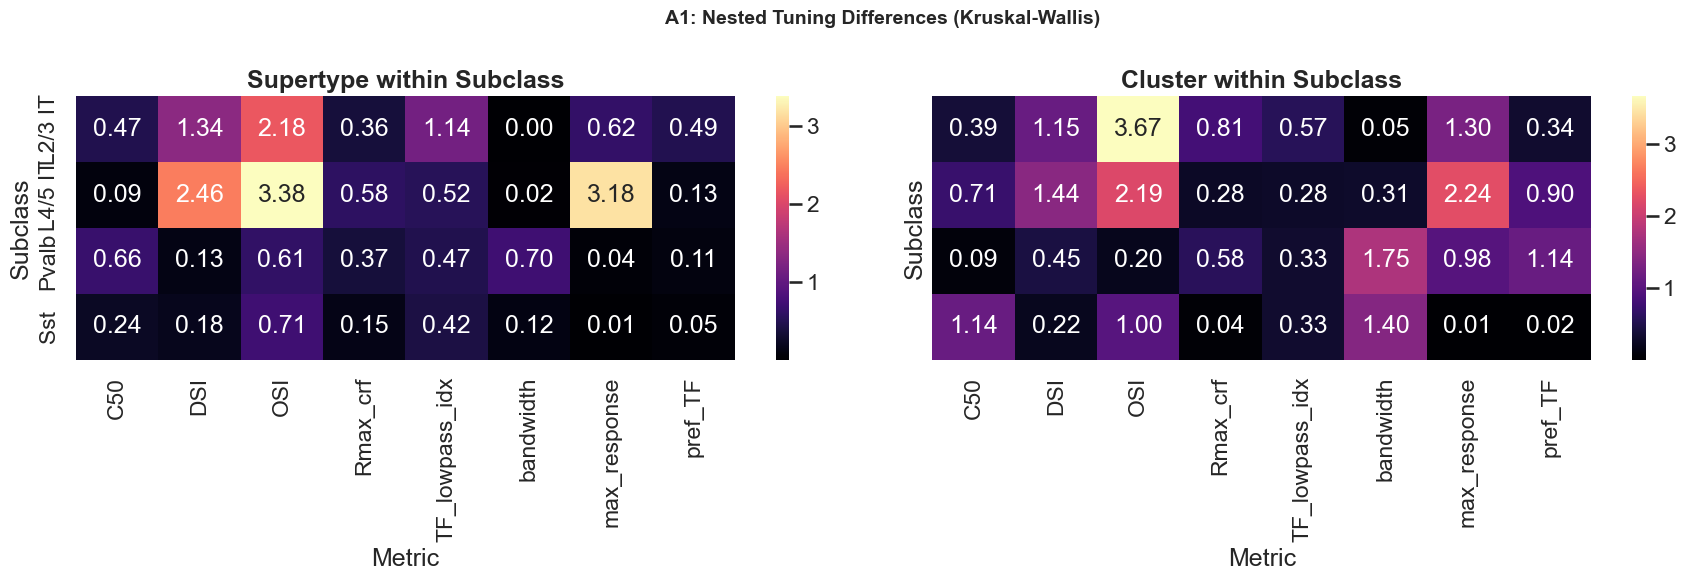

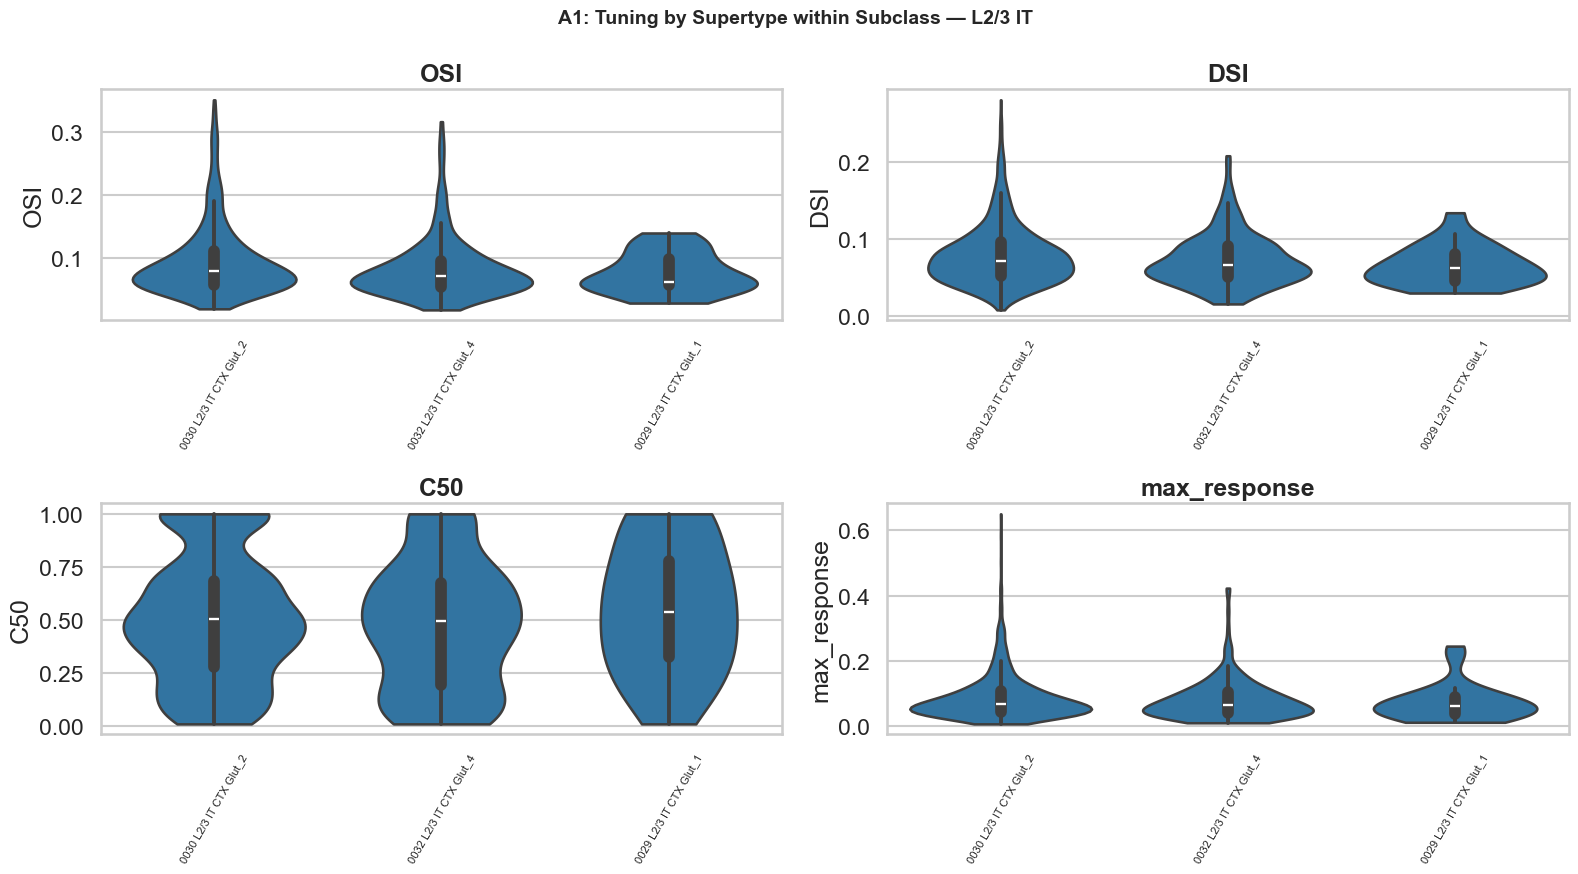

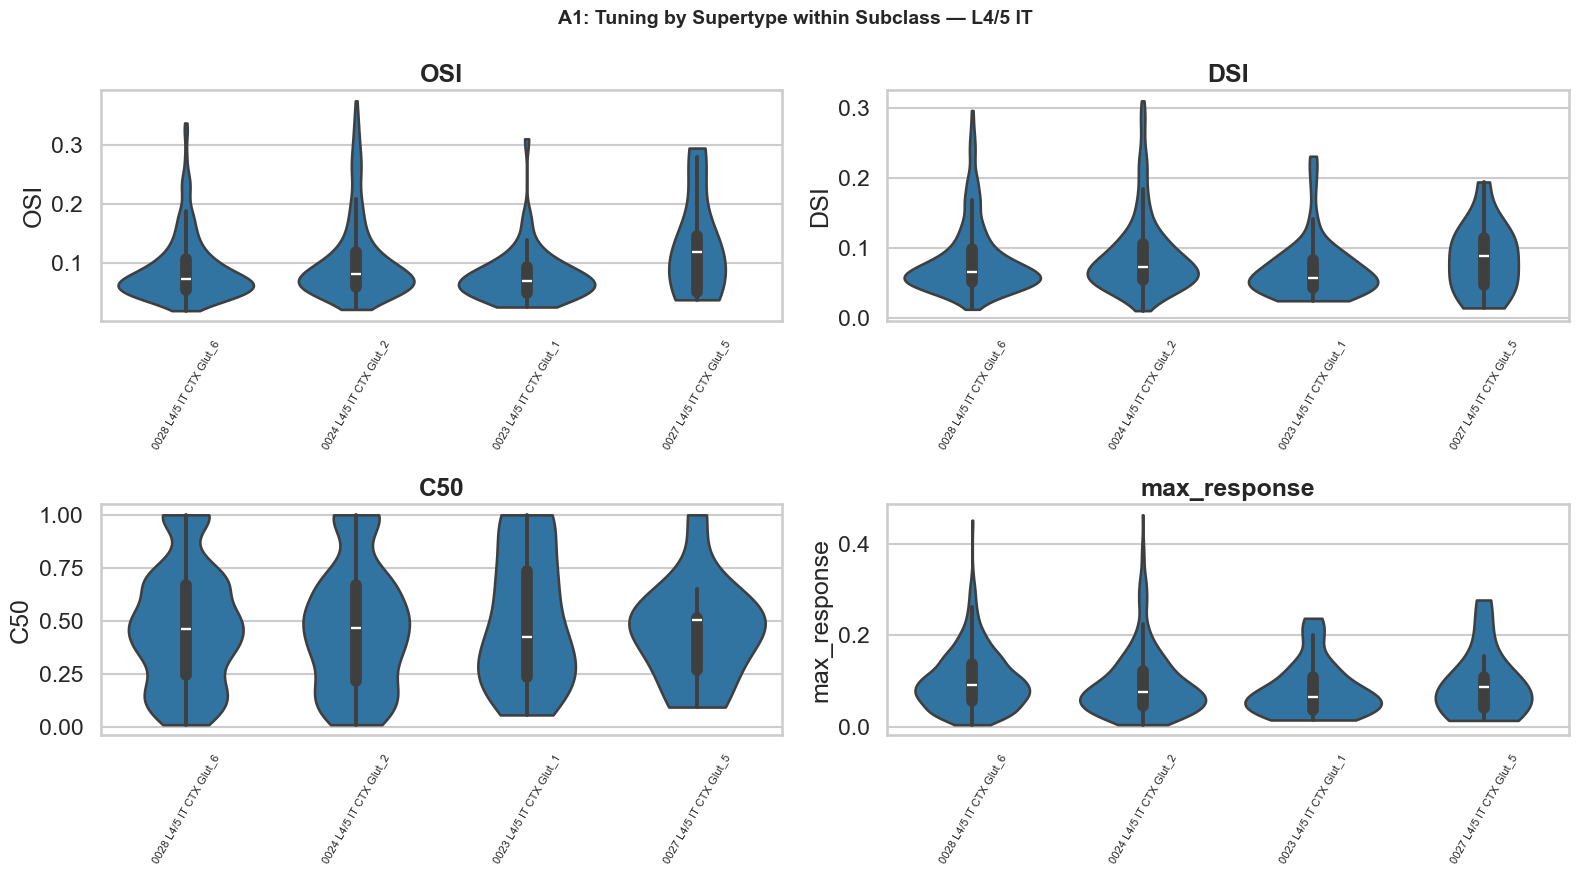

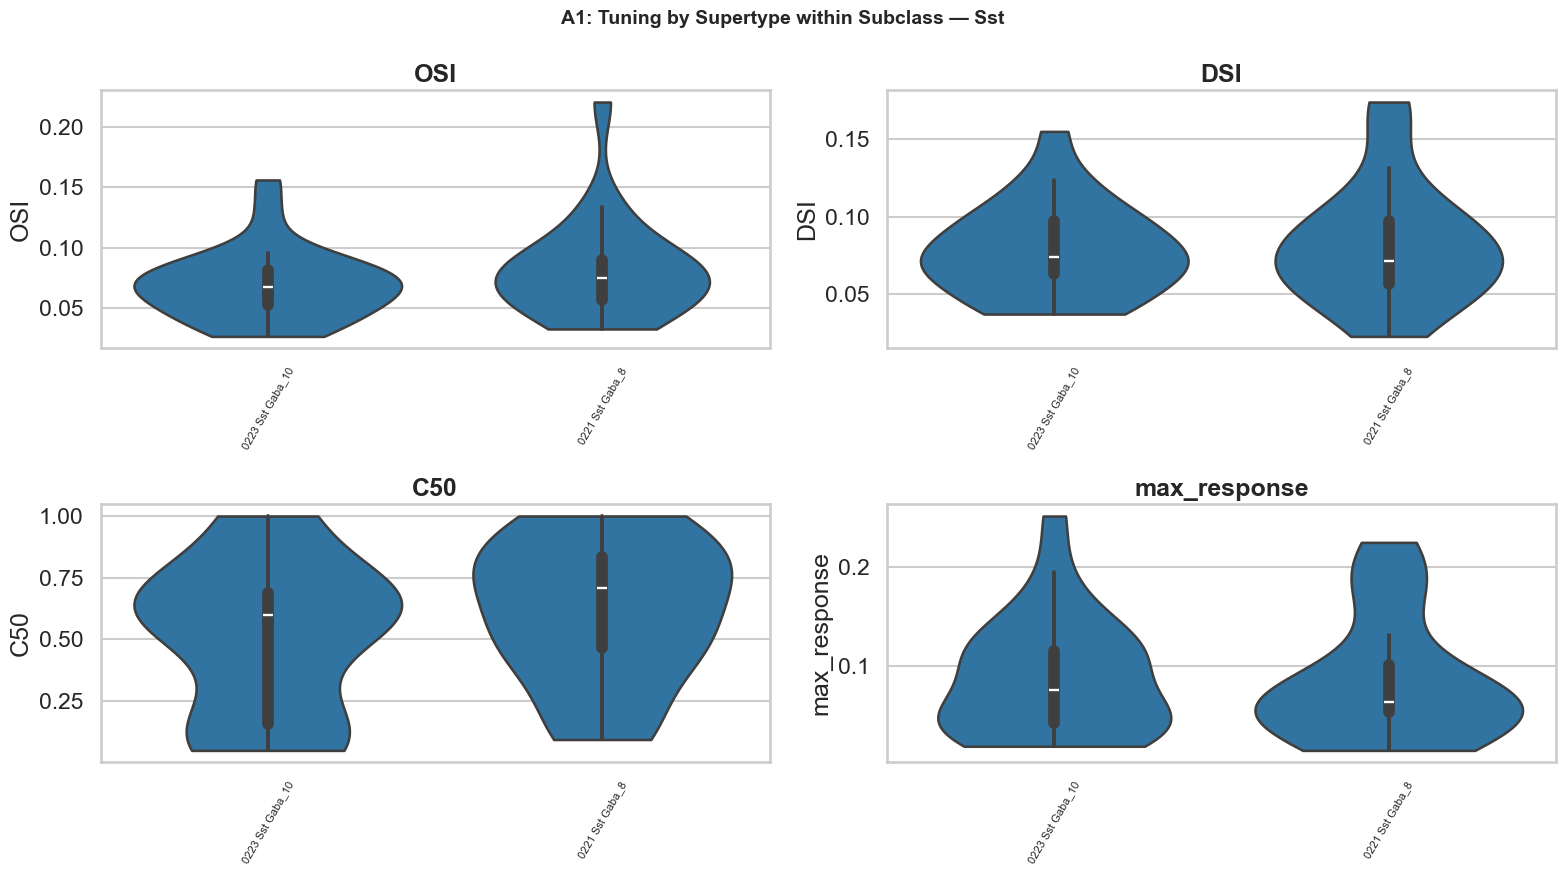

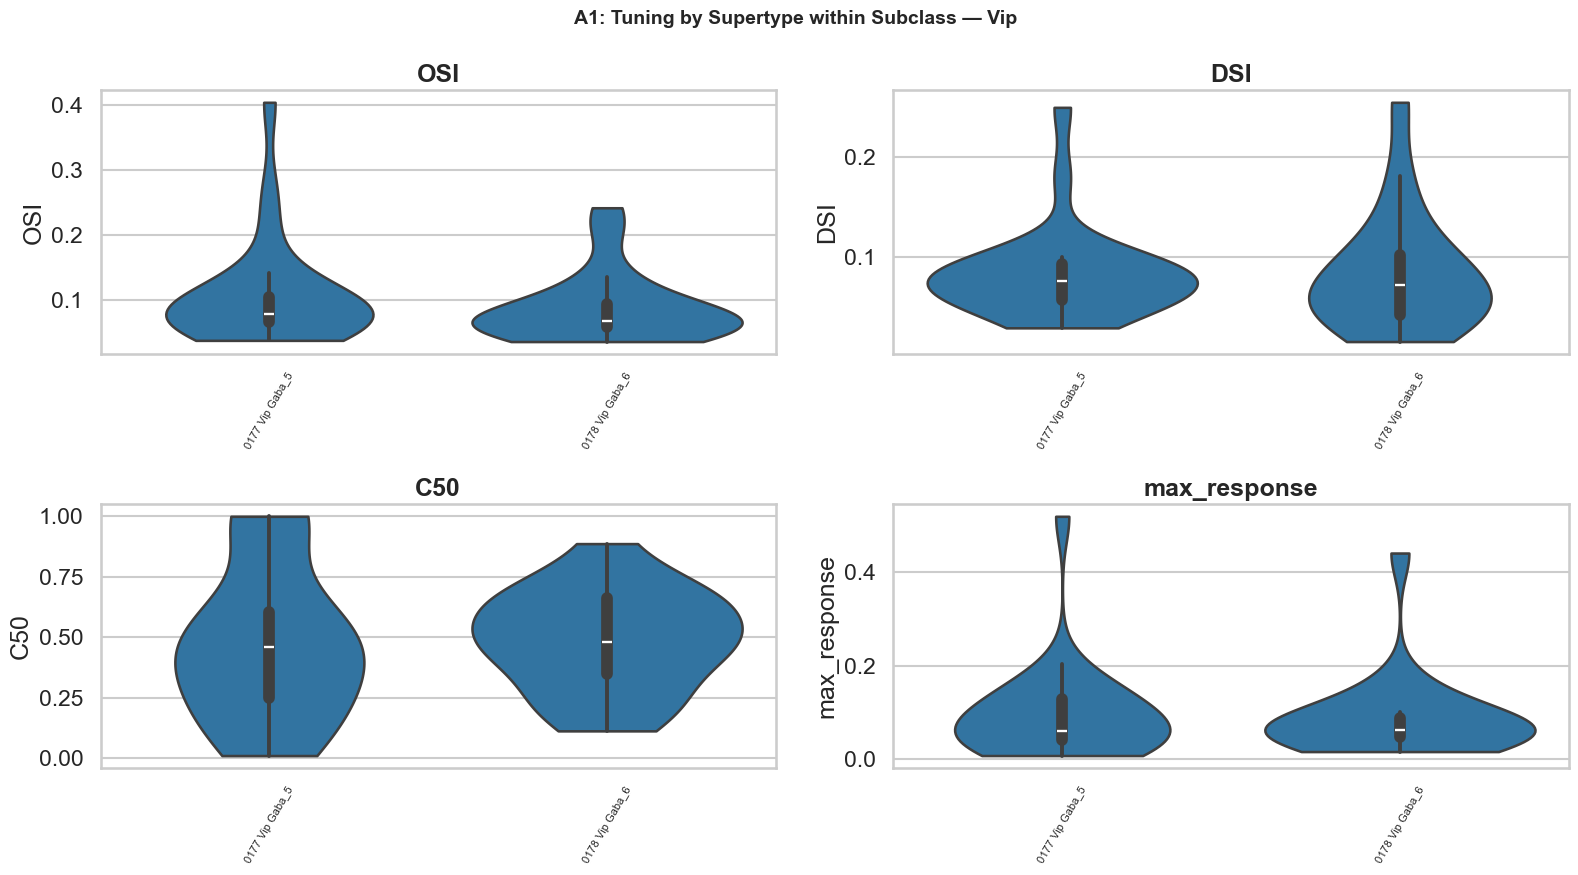

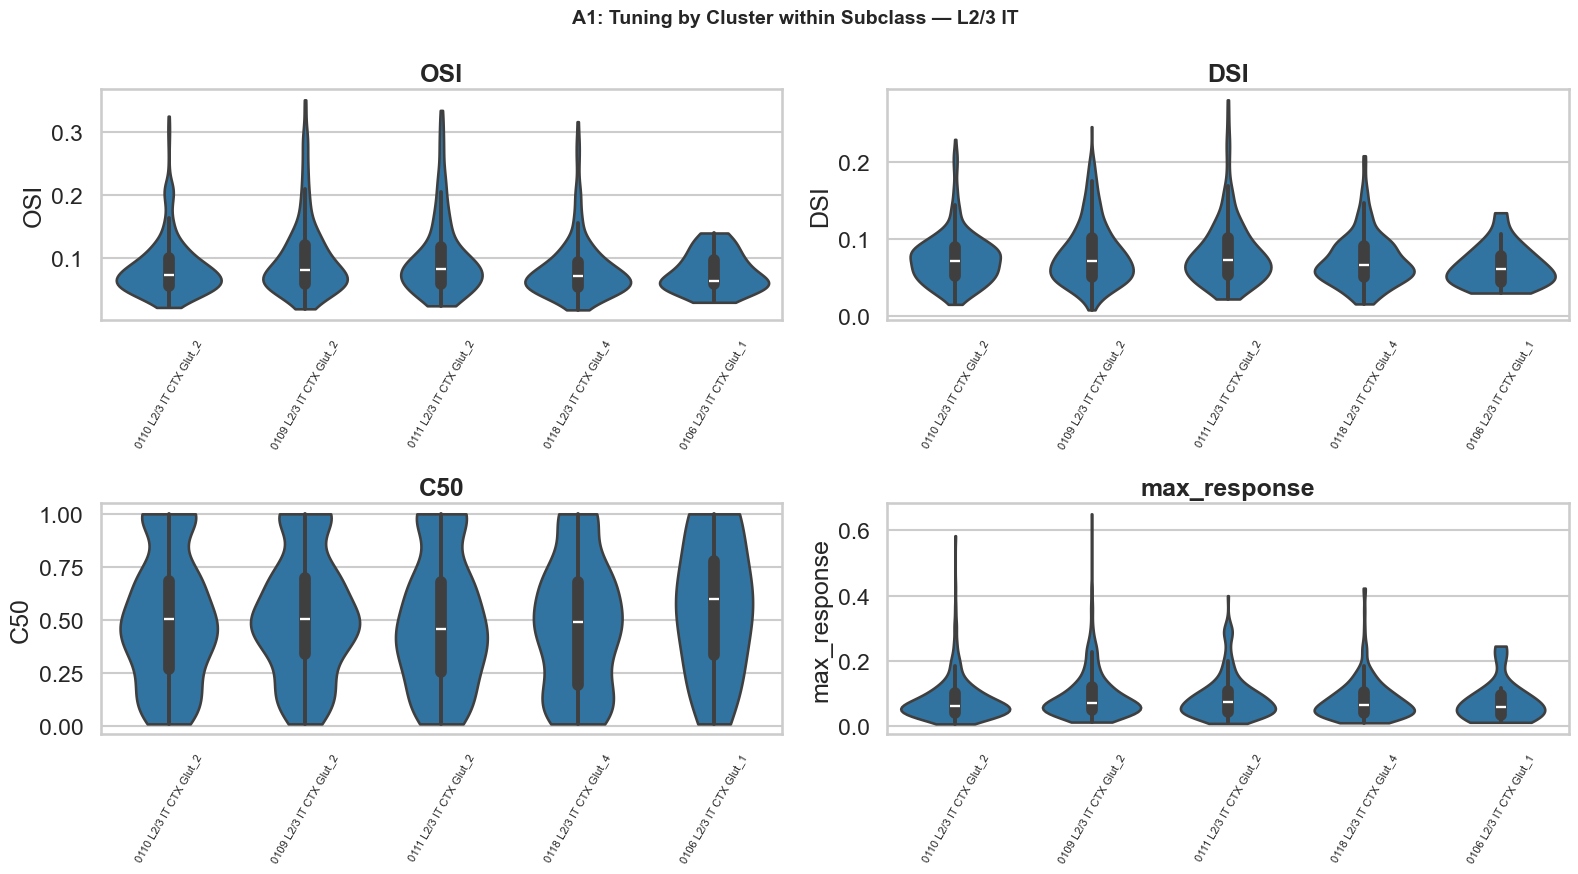

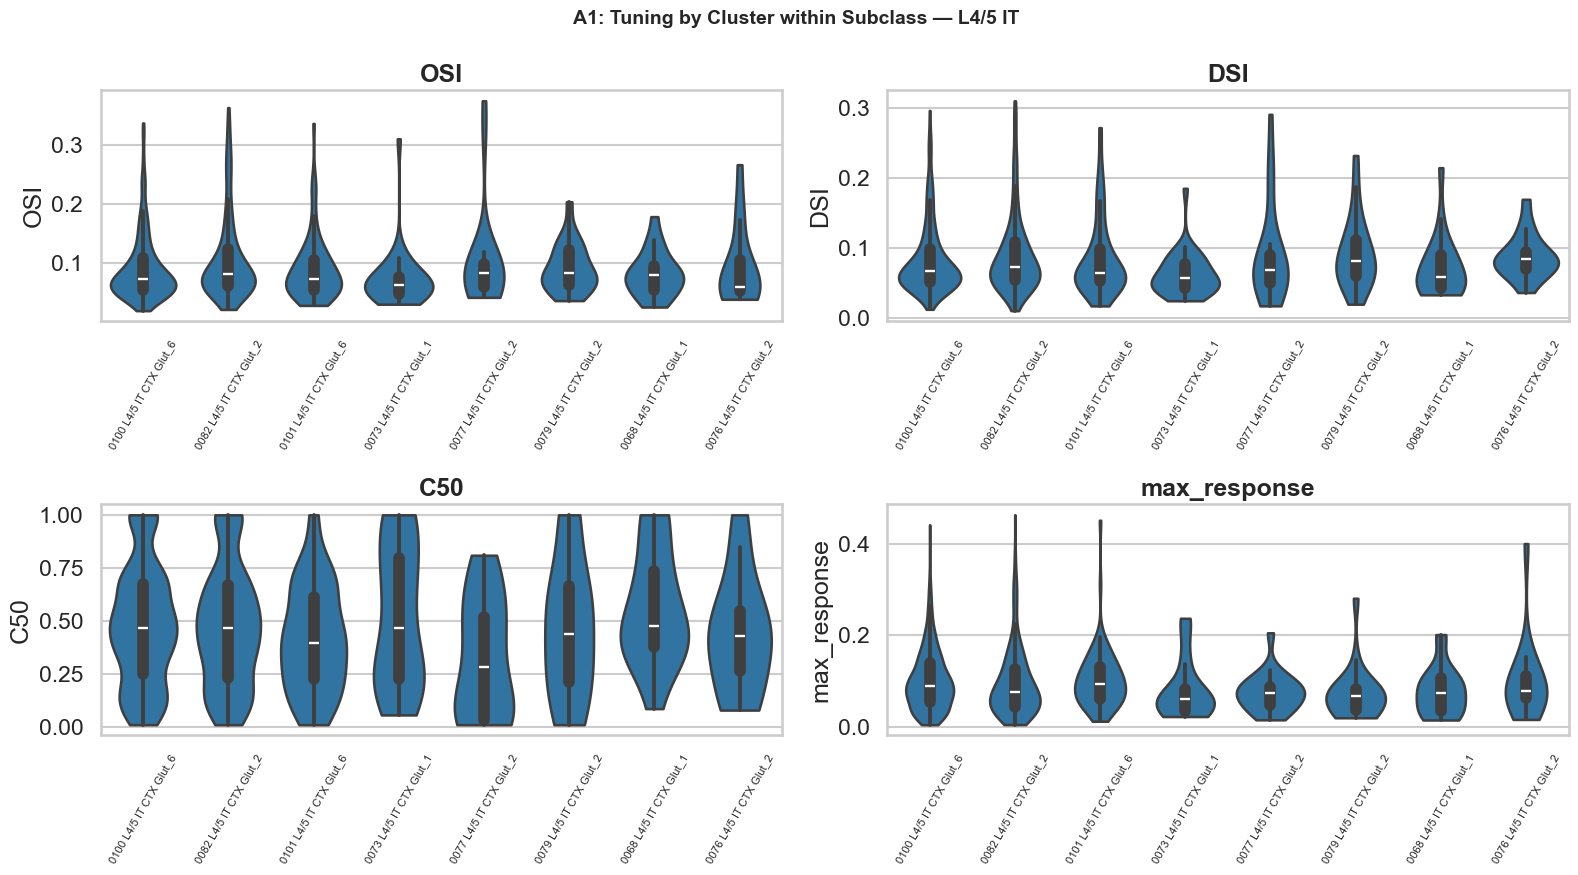

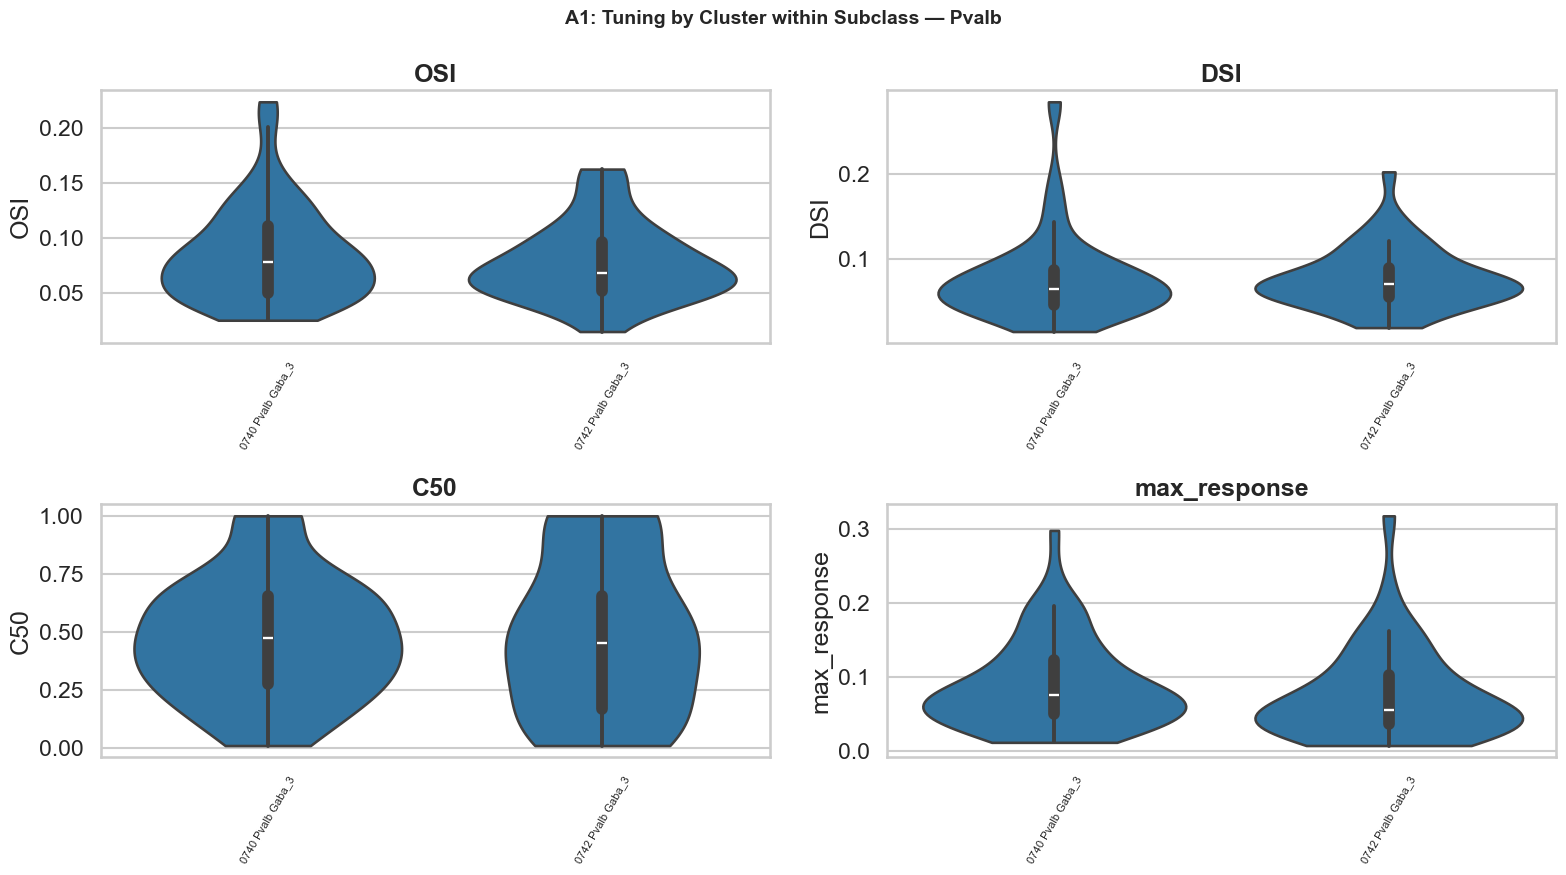

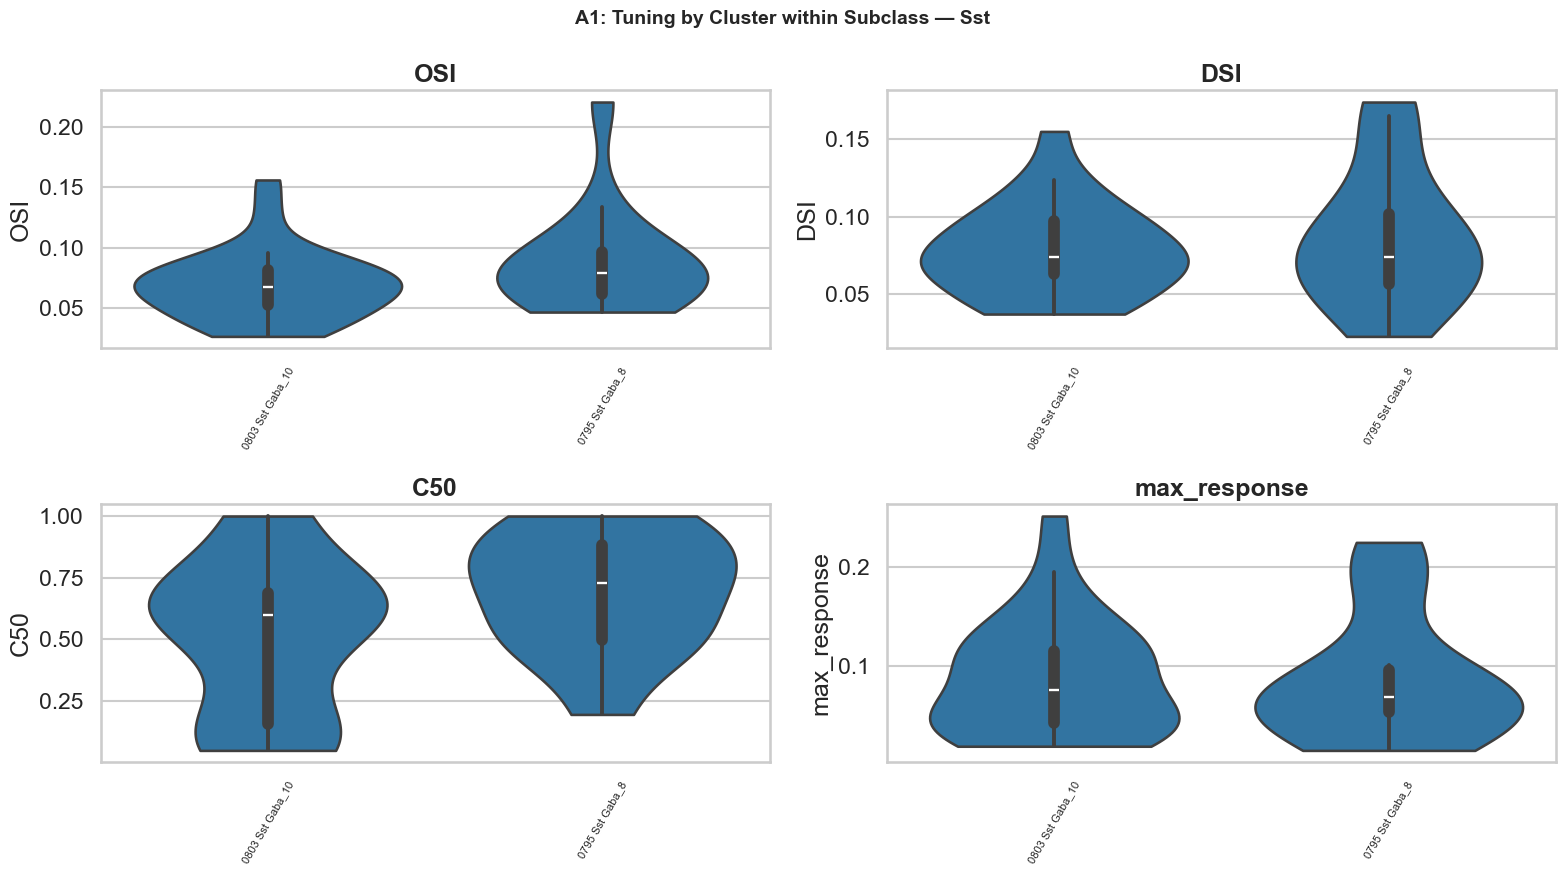

In [36]:
# ══════════════════════════════════════════════════════════════════════
# A1.3b  Nested analyses:
#        (1) supertype within subclass
#        (2) cluster within subclass
# ══════════════════════════════════════════════════════════════════════

def _nested_kruskal(df, parent_col, child_col, metrics, min_cells_per_child=10):
    rows = []
    for parent in present_subclasses:
        d0 = df[df[parent_col] == parent].copy()
        if d0.empty:
            continue

        # keep sufficiently populated child groups
        child_counts = d0[child_col].value_counts()
        keep_children = child_counts[child_counts >= min_cells_per_child].index
        d0 = d0[d0[child_col].isin(keep_children)]

        if d0[child_col].nunique() < 2:
            continue

        for met in metrics:
            groups = [g[met].dropna().values for _, g in d0.groupby(child_col)]
            groups = [g for g in groups if len(g) >= 3]
            if len(groups) < 2:
                continue
            stat, p = kruskal(*groups)
            rows.append({
                'subclass': parent,
                'subclass_short': SUBCLASS_SHORT.get(parent, parent),
                'level': child_col,
                'metric': met,
                'H': stat,
                'p': p,
                'n_groups': d0[child_col].nunique()
            })
    return pd.DataFrame(rows)

# ── Run nested tests ──
nested_supertype = _nested_kruskal(
    tuning_df, parent_col='subclass', child_col='supertype',
    metrics=metrics, min_cells_per_child=10
)
nested_cluster = _nested_kruskal(
    tuning_df, parent_col='subclass', child_col='cluster',
    metrics=metrics, min_cells_per_child=10
)

print("=== Kruskal-Wallis: supertype within subclass ===")
if len(nested_supertype):
    for _, r in nested_supertype.sort_values(['metric', 'p']).iterrows():
        sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'ns'
        print(f"  {r['subclass_short']:8s} | {r['metric']:14s}: H={r['H']:8.2f}, p={r['p']:.2e}, groups={int(r['n_groups'])} {sig}")
else:
    print("  No valid tests (insufficient group sizes).")

print("\n=== Kruskal-Wallis: cluster within subclass ===")
if len(nested_cluster):
    for _, r in nested_cluster.sort_values(['metric', 'p']).iterrows():
        sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'ns'
        print(f"  {r['subclass_short']:8s} | {r['metric']:14s}: H={r['H']:8.2f}, p={r['p']:.2e}, groups={int(r['n_groups'])} {sig}")
else:
    print("  No valid tests (insufficient group sizes).")

# ── Heatmap summary: -log10(p) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, res_df, title in [
    (axes[0], nested_supertype, 'Supertype within Subclass'),
    (axes[1], nested_cluster, 'Cluster within Subclass')
]:
    if len(res_df):
        piv = res_df.pivot_table(index='subclass_short', columns='metric', values='p', aggfunc='min')
        sns.heatmap(-np.log10(piv.clip(lower=1e-50)), cmap='magma', ax=ax, annot=True, fmt='.2f')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Metric')
        ax.set_ylabel('Subclass')
    else:
        ax.axis('off')
        ax.set_title(f'{title}\n(no valid tests)', fontweight='bold')

plt.suptitle('A1: Nested Tuning Differences (Kruskal-Wallis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Violin plots per subclass for nested levels (selected metrics for readability) ──
plot_metrics_nested = ['OSI', 'DSI', 'C50', 'max_response']

def _plot_nested_violins_one_level(df, child_col, title_prefix, min_cells=10, max_children=None):
    for sc in present_subclasses:
        d = df[df['subclass'] == sc].copy()
        counts = d[child_col].value_counts()
        keep = counts[counts >= min_cells].index

        if max_children is not None and len(keep) > max_children:
            keep = counts.loc[keep].sort_values(ascending=False).head(max_children).index

        d = d[d[child_col].isin(keep)]
        if d[child_col].nunique() < 2:
            continue

        fig, axes = plt.subplots(2, 2, figsize=(16, 9))
        for ax, met in zip(axes.flat, plot_metrics_nested):
            sns.violinplot(
                data=d, x=child_col, y=met, order=list(keep),
                cut=0, inner='box', ax=ax
            )
            ax.set_title(met, fontweight='bold')
            ax.tick_params(axis='x', rotation=60, labelsize=8)
            ax.set_xlabel('')

        plt.suptitle(f"{title_prefix} — {SUBCLASS_SHORT.get(sc, sc)}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# supertype plots (usually manageable)
_plot_nested_violins_one_level(
    tuning_df, child_col='supertype',
    title_prefix='A1: Tuning by Supertype within Subclass',
    min_cells=10, max_children=None
)

# cluster plots (limit groups per subclass for readability)
_plot_nested_violins_one_level(
    tuning_df, child_col='cluster',
    title_prefix='A1: Tuning by Cluster within Subclass',
    min_cells=10, max_children=8
)

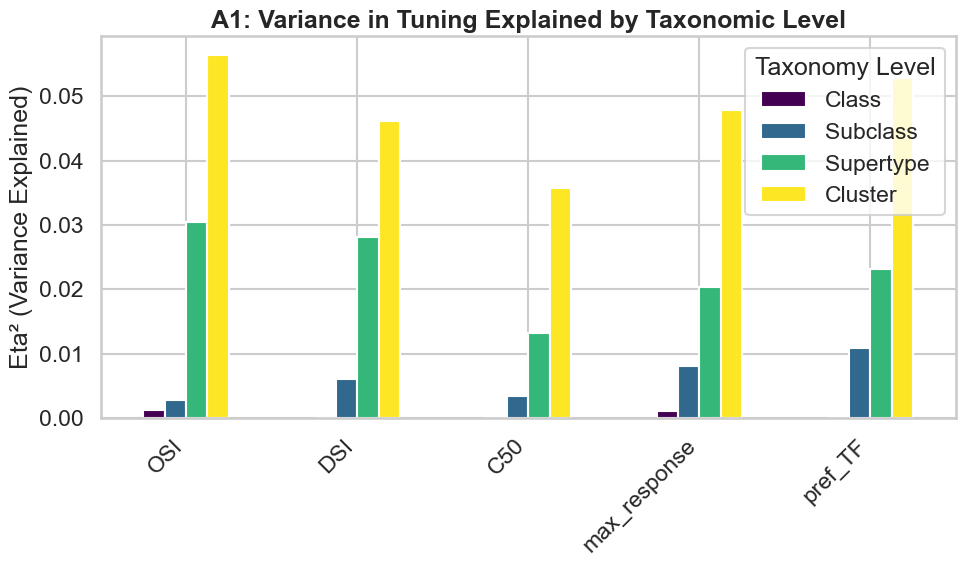

In [37]:
# ══════════════════════════════════════════════════════════════════════
# A1.4  Variance decomposition: how much variance in tuning is explained
#       at each level of the taxonomy? (class → subclass → supertype → cluster)
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

levels = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
level_labels = ['Class', 'Subclass', 'Supertype', 'Cluster']

r2_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']:
    valid = tuning_df[met].notna()
    y = tuning_df.loc[valid, met].values
    r2_per_level = []
    for lvl in levels:
        labels = obs.loc[valid.values, lvl].values if lvl in obs.columns else tuning_df.loc[valid, lvl.replace('_name', '')].values
        le = LabelEncoder()
        groups = le.fit_transform(labels)
        # R² from group means (eta-squared)
        group_means = np.array([np.mean(y[groups == g]) for g in range(len(le.classes_))])
        y_pred = group_means[groups]
        ss_between = np.sum((y_pred - np.mean(y))**2)
        ss_total = np.sum((y - np.mean(y))**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        r2_per_level.append(eta2)
    r2_results[met] = r2_per_level

# ── Visualization: Stacked bar of variance explained ──
r2_df = pd.DataFrame(r2_results, index=level_labels)
fig, ax = plt.subplots(figsize=(10, 6))
r2_df.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Eta² (Variance Explained)')
ax.set_title('A1: Variance in Tuning Explained by Taxonomic Level', fontweight='bold')
ax.legend(title='Taxonomy Level')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:

# ── Confusion matrix: predict subclass from tuning ──
feature_cols = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF', 'TF_lowpass_idx']
valid = tuning_df[feature_cols].notna().all(axis=1)
X_feat = tuning_df.loc[valid, feature_cols].values
y_label = tuning_df.loc[valid, 'subclass'].values

# Only subclasses with enough cells
from collections import Counter
counts = Counter(y_label)
keep = [k for k, v in counts.items() if v >= 10]
mask_keep = np.isin(y_label, keep)
X_feat_k, y_label_k = X_feat[mask_keep], y_label[mask_keep]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat_k)

# Leave-one-mouse-out cross-validation
mouse_ids = tuning_df.loc[valid, 'mouse_id'].values[mask_keep]
logo = LeaveOneGroupOut()
y_pred_all, y_true_all = [], []
for train_idx, test_idx in logo.split(X_scaled, y_label_k, groups=mouse_ids):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_scaled[train_idx], y_label_k[train_idx])
    y_pred_all.extend(clf.predict(X_scaled[test_idx]))
    y_true_all.extend(y_label_k[test_idx])

acc = accuracy_score(y_true_all, y_pred_all)
print(f"\nSubclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = {acc:.3f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=keep)
short_labels = [SUBCLASS_SHORT.get(k, k) for k in keep]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=short_labels, yticklabels=short_labels,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'A1: Subclass Prediction from Tuning (acc={acc:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A1.4  Variance decomposition: how much variance in tuning is explained
#       at each level of the taxonomy? (class → subclass → supertype → cluster)
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

levels = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
level_labels = ['Class', 'Subclass', 'Supertype', 'Cluster']

r2_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']:
    valid = tuning_df[met].notna()
    y = tuning_df.loc[valid, met].values
    r2_per_level = []
    for lvl in levels:
        labels = obs.loc[valid.values, lvl].values if lvl in obs.columns else tuning_df.loc[valid, lvl.replace('_name', '')].values
        le = LabelEncoder()
        groups = le.fit_transform(labels)
        # R² from group means (eta-squared)
        group_means = np.array([np.mean(y[groups == g]) for g in range(len(le.classes_))])
        y_pred = group_means[groups]
        ss_between = np.sum((y_pred - np.mean(y))**2)
        ss_total = np.sum((y - np.mean(y))**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        r2_per_level.append(eta2)
    r2_results[met] = r2_per_level

# ── Visualization: Stacked bar of variance explained ──
r2_df = pd.DataFrame(r2_results, index=level_labels)
fig, ax = plt.subplots(figsize=(10, 6))
r2_df.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Eta² (Variance Explained)')
ax.set_title('A1: Variance in Tuning Explained by Taxonomic Level', fontweight='bold')
ax.legend(title='Taxonomy Level')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Confusion matrix: predict subclass from tuning ──
feature_cols = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF', 'TF_lowpass_idx']
valid = tuning_df[feature_cols].notna().all(axis=1)
X_feat = tuning_df.loc[valid, feature_cols].values
y_label = tuning_df.loc[valid, 'subclass'].values

# Only subclasses with enough cells
from collections import Counter
counts = Counter(y_label)
keep = [k for k, v in counts.items() if v >= 10]
mask_keep = np.isin(y_label, keep)
X_feat_k, y_label_k = X_feat[mask_keep], y_label[mask_keep]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat_k)

# Leave-one-mouse-out cross-validation
mouse_ids = tuning_df.loc[valid, 'mouse_id'].values[mask_keep]
logo = LeaveOneGroupOut()
y_pred_all, y_true_all = [], []
for train_idx, test_idx in logo.split(X_scaled, y_label_k, groups=mouse_ids):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_scaled[train_idx], y_label_k[train_idx])
    y_pred_all.extend(clf.predict(X_scaled[test_idx]))
    y_true_all.extend(y_label_k[test_idx])

acc = accuracy_score(y_true_all, y_pred_all)
print(f"\nSubclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = {acc:.3f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=keep)
short_labels = [SUBCLASS_SHORT.get(k, k) for k in keep]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=short_labels, yticklabels=short_labels,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'A1: Subclass Prediction from Tuning (acc={acc:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===

--- OSI ---

--- DSI ---

--- C50 ---

--- max_response ---
  L2/3 IT  vs L4/5 IT : U=685978, p_adj=6.89e-08 ***



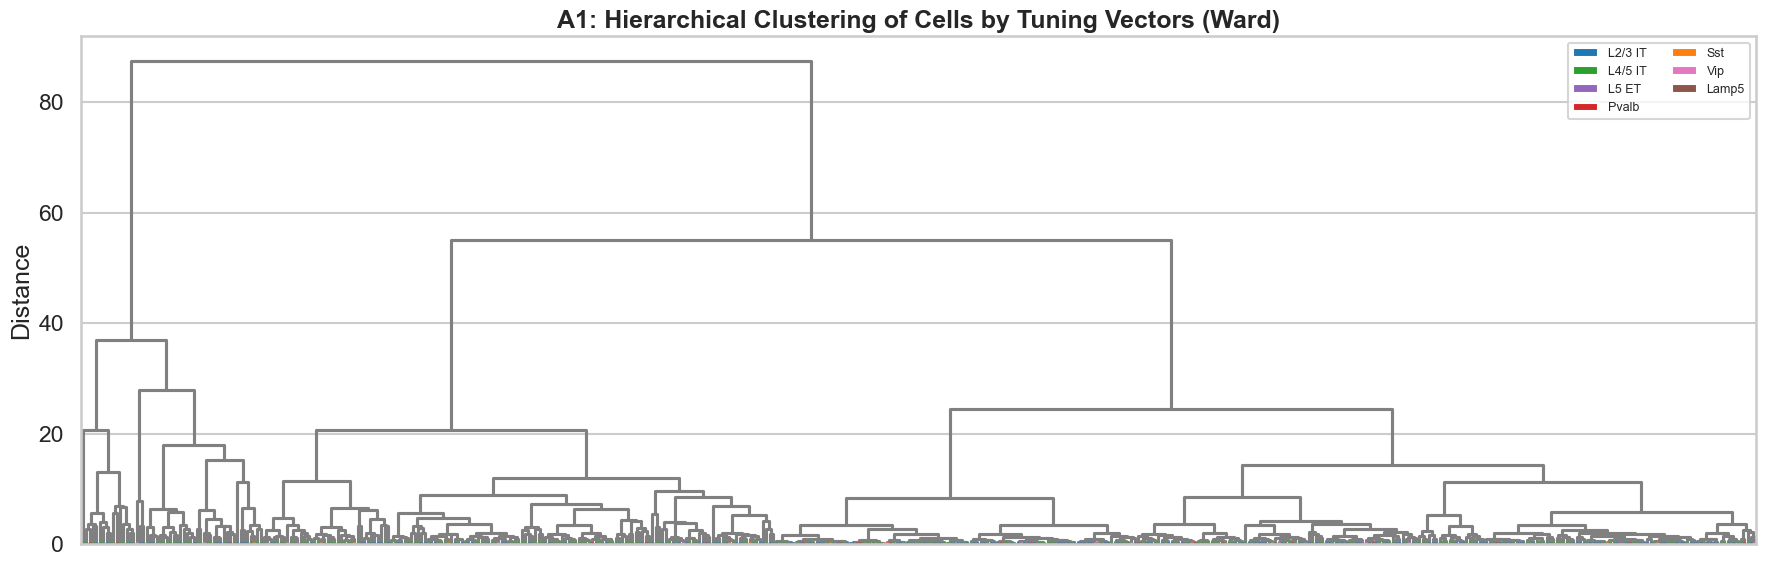

In [33]:
# ══════════════════════════════════════════════════════════════════════
# A1.5  Post-hoc pairwise comparisons (Dunn's test) + hierarchical
#       clustering dendrogram of cells by tuning vectors
# ══════════════════════════════════════════════════════════════════════
from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# ── Dunn-style pairwise Mann-Whitney U with Bonferroni correction ──
print("=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===\n")
for met in ['OSI', 'DSI', 'C50', 'max_response']:
    print(f"--- {met} ---")
    pairs = list(combinations(present_subclasses, 2))
    n_pairs = len(pairs)
    for s1, s2 in pairs:
        g1 = tuning_df.loc[tuning_df['subclass'] == s1, met].dropna()
        g2 = tuning_df.loc[tuning_df['subclass'] == s2, met].dropna()
        if len(g1) < 3 or len(g2) < 3:
            continue
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        p_adj = min(p * n_pairs, 1.0)  # Bonferroni
        sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
        if p_adj < 0.05:
            print(f"  {SUBCLASS_SHORT[s1]:8s} vs {SUBCLASS_SHORT[s2]:8s}: U={stat:.0f}, p_adj={p_adj:.2e} {sig}")
    print()

# ── Hierarchical clustering dendrogram based on tuning vectors ──
# Build a tuning feature vector per cell: [ori_responses (8), crf_responses (5), tf_responses (5)]
tuning_vectors = np.hstack([ori_responses_all, crf_responses_all, tf_responses_all])  # n_cells x 18
valid_cells = ~np.isnan(tuning_vectors).any(axis=1) & (np.std(tuning_vectors, axis=1) > 1e-6)
tv_clean = tuning_vectors[valid_cells]
tv_labels = obs['subclass_name'].values[valid_cells]
n_show = min(500, tv_clean.shape[0])  # subsample for readability

rng = np.random.default_rng(42)
idx = rng.choice(tv_clean.shape[0], size=n_show, replace=False)
tv_sub = tv_clean[idx]
labels_sub = tv_labels[idx]

# Z-score each feature
tv_sub_z = (tv_sub - tv_sub.mean(axis=0)) / (tv_sub.std(axis=0) + 1e-8)

Z = linkage(tv_sub_z, method='ward', metric='euclidean')
label_colors = {s: SUBCLASS_COLORS[s] for s in present_subclasses}
leaf_colors = [label_colors.get(labels_sub[i], '#333333') for i in range(n_show)]

fig, ax = plt.subplots(figsize=(18, 6))
dn = dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color='gray')
# Color leaves
xlbls = ax.get_xticklabels()
leaves = dn['leaves']
for i, leaf_idx in enumerate(leaves):
    x = 5 + 10 * i
    ax.plot(x, 0, 'o', color=leaf_colors[leaf_idx], markersize=2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SUBCLASS_COLORS[s], label=SUBCLASS_SHORT[s])
                   for s in present_subclasses]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=2)
ax.set_title('A1: Hierarchical Clustering of Cells by Tuning Vectors (Ward)', fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## A2: Gene Expression Predicts Functional Response Properties

Correlate each gene's expression with tuning metrics, run LASSO regression, and identify co-expression modules.

Total gene-metric pairs tested: 1485
Significant (FDR<0.05): 197


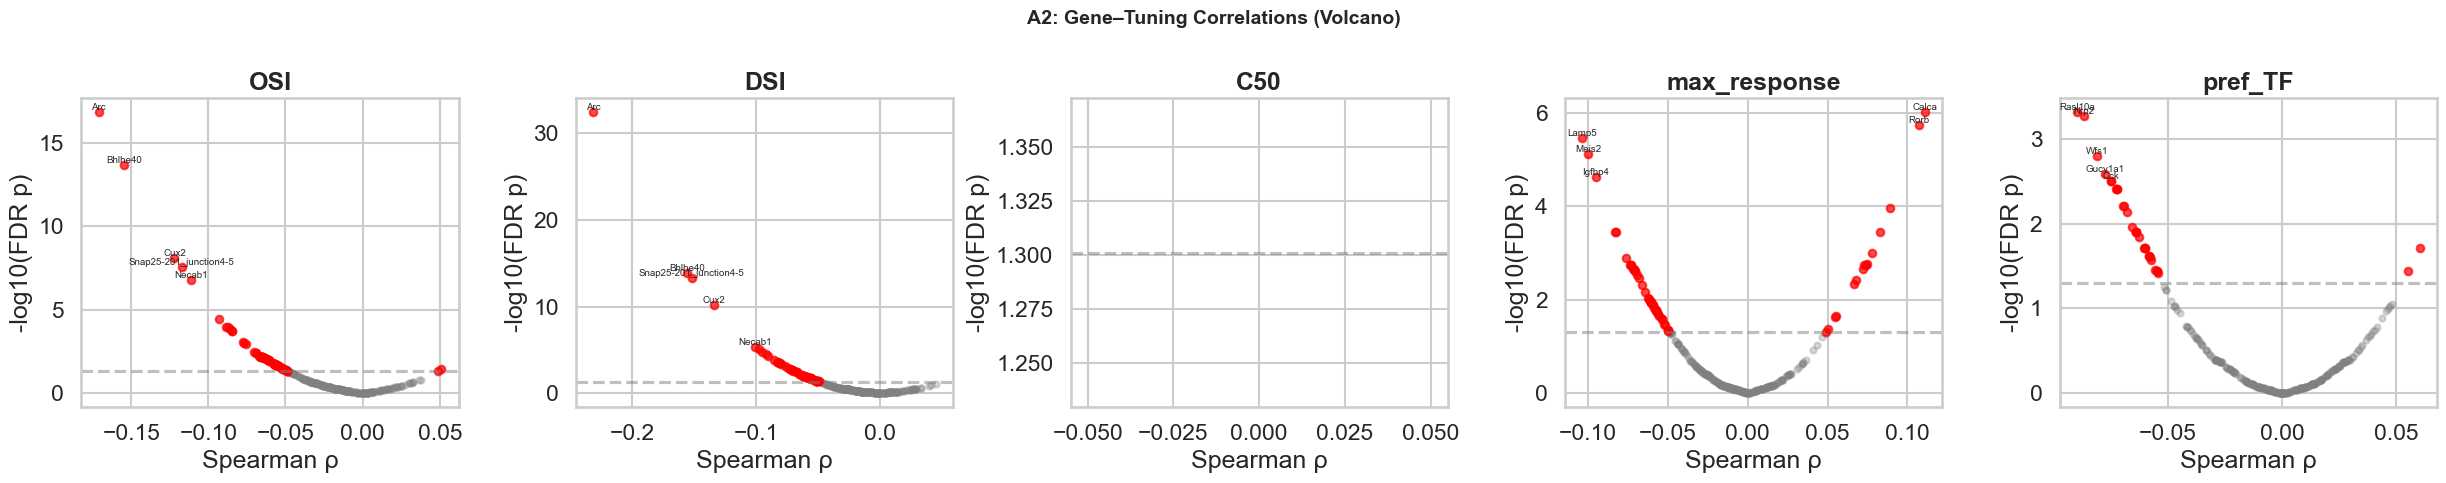


Within-subclass correlations computed: 3552
subclass  metric      
L2/3 IT   OSI             67
          max_response    13
L4/5 IT   OSI             68
          max_response    39
L5 ET     OSI              4
          max_response     5
Lamp5     OSI              4
          max_response     5
Pvalb     OSI             34
          max_response    13
Sst       OSI              2
          max_response    16
Vip       OSI              7
          max_response     8
dtype: int64


In [34]:
# ══════════════════════════════════════════════════════════════════════
# A2.1  Gene–Tuning Spearman Correlations (whole population + within-subclass)
# ══════════════════════════════════════════════════════════════════════
from statsmodels.stats.multitest import multipletests

gene_expr = obs[GENE_COLS].values.astype(float)  # n_cells x n_genes
target_metrics = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']

# ── Whole-population correlations ──
corr_results = []
for gi, gene in enumerate(GENE_COLS):
    gx = gene_expr[:, gi]
    if np.std(gx) < 1e-6:
        continue
    for met in target_metrics:
        y = tuning_df[met].values
        valid = ~np.isnan(y) & ~np.isnan(gx)
        if valid.sum() < 20:
            continue
        rho, p = spearmanr(gx[valid], y[valid])
        corr_results.append({'gene': gene, 'metric': met, 'rho': rho, 'p': p})

corr_df = pd.DataFrame(corr_results)
# FDR correction per metric
for met in target_metrics:
    mask = corr_df['metric'] == met
    if mask.sum() > 0:
        _, pvals_adj, _, _ = multipletests(corr_df.loc[mask, 'p'], method='fdr_bh')
        corr_df.loc[mask, 'p_adj'] = pvals_adj

corr_df['sig'] = corr_df['p_adj'] < 0.05
print(f"Total gene-metric pairs tested: {len(corr_df)}")
print(f"Significant (FDR<0.05): {corr_df['sig'].sum()}")

# ── Volcano plot for each metric ──
fig, axes = plt.subplots(1, len(target_metrics), figsize=(5*len(target_metrics), 5))
for ax, met in zip(axes, target_metrics):
    sub = corr_df[corr_df['metric'] == met].copy()
    sub['-log10p'] = -np.log10(sub['p_adj'].clip(1e-50))
    ax.scatter(sub.loc[~sub['sig'], 'rho'], sub.loc[~sub['sig'], '-log10p'],
               alpha=0.3, s=20, c='gray')
    ax.scatter(sub.loc[sub['sig'], 'rho'], sub.loc[sub['sig'], '-log10p'],
               alpha=0.7, s=30, c='red')
    # Label top genes
    top = sub.nlargest(5, '-log10p')
    for _, row in top.iterrows():
        ax.annotate(row['gene'], (row['rho'], row['-log10p']), fontsize=7,
                   ha='center', va='bottom')
    ax.axhline(-np.log10(0.05), ls='--', color='gray', alpha=0.5)
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('-log10(FDR p)')
    ax.set_title(met, fontweight='bold')
plt.suptitle('A2: Gene–Tuning Correlations (Volcano)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Within-subclass correlations (control for cell-type effects) ──
within_corr = []
for sc in present_subclasses:
    sc_mask = obs['subclass_name'].values == sc
    if sc_mask.sum() < 20:
        continue
    for gi, gene in enumerate(GENE_COLS):
        gx = gene_expr[sc_mask, gi]
        if np.std(gx) < 1e-6:
            continue
        for met in ['OSI', 'max_response']:
            y = tuning_df.loc[sc_mask, met].values
            valid = ~np.isnan(y) & ~np.isnan(gx)
            if valid.sum() < 10:
                continue
            rho, p = spearmanr(gx[valid], y[valid])
            within_corr.append({'subclass': SUBCLASS_SHORT[sc], 'gene': gene, 'metric': met, 'rho': rho, 'p': p})

within_df = pd.DataFrame(within_corr)
print(f"\nWithin-subclass correlations computed: {len(within_df)}")
print(within_df.groupby(['subclass', 'metric']).apply(lambda x: (x['p'] < 0.05).sum()).head(20))

Genes with non-zero variance: 297

OSI: R²(CV) = -0.618, r = -0.287
  Top predictive genes: [(np.str_('EGFP'), '0.009'), (np.str_('Bhlhe40'), '-0.008'), (np.str_('Lamp5'), '0.006'), (np.str_('Arc'), '-0.005'), (np.str_('Snap25-201_junction4-5'), '-0.004'), (np.str_('Cux2'), '-0.004'), (np.str_('Bdnf'), '0.004'), (np.str_('SYFP2'), '-0.003')]

DSI: R²(CV) = -0.583, r = -0.427
  Top predictive genes: [(np.str_('Arc'), '-0.005'), (np.str_('EGFP'), '0.005'), (np.str_('Snap25-201_junction4-5'), '-0.003'), (np.str_('Pde7b'), '0.002'), (np.str_('Bhlhe40'), '-0.002'), (np.str_('Slc17a6'), '0.002'), (np.str_('Bdnf'), '0.002'), (np.str_('Rln1'), '0.001')]

C50: R²(CV) = -0.007, r = -0.066
  Top predictive genes: []

max_response: R²(CV) = -0.053, r = -0.198
  Top predictive genes: [(np.str_('Arc'), '-0.003'), (np.str_('Gfra2'), '0.001'), (np.str_('Rorb'), '0.001'), (np.str_('EGFP'), '0.001'), (np.str_('Meis2'), '-0.001'), (np.str_('Tac2'), '0.000'), (np.str_('Cyp1b1'), '0.000'), (np.str_('Sla'),

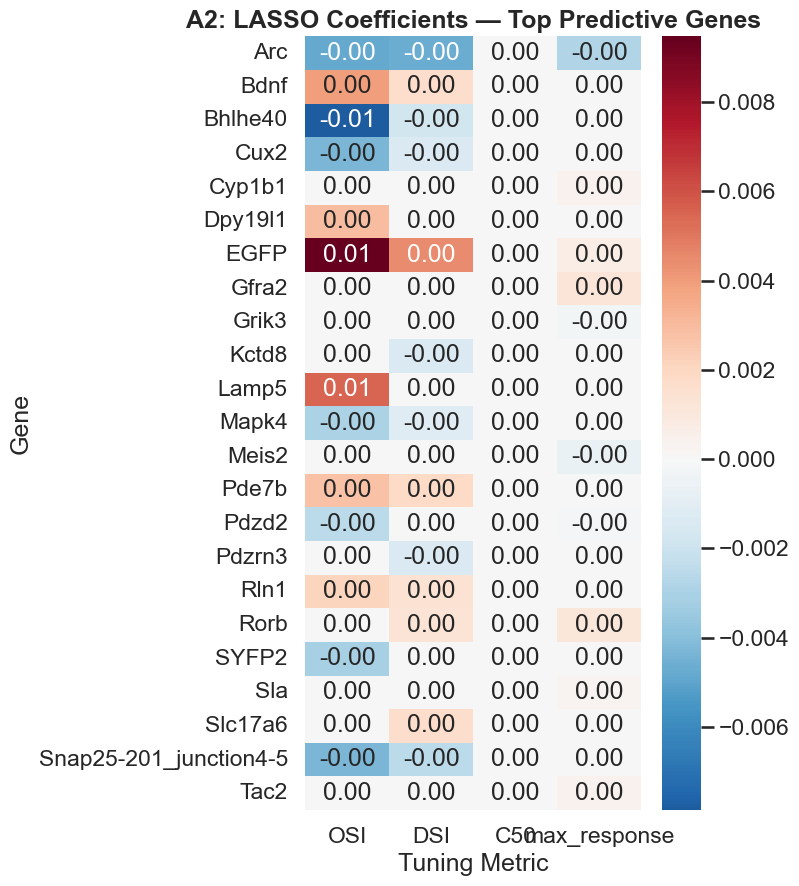

In [35]:
# ══════════════════════════════════════════════════════════════════════
# A2.2  LASSO / Elastic-Net: predict tuning from gene expression
# ══════════════════════════════════════════════════════════════════════

gene_matrix = obs[GENE_COLS].values.astype(float)
# Impute NaNs with zero (most genes are zero for many cells)
gene_matrix = np.nan_to_num(gene_matrix, nan=0.0)
# Remove zero-variance genes
nonzero_var = np.std(gene_matrix, axis=0) > 1e-6
gene_matrix_filt = gene_matrix[:, nonzero_var]
gene_names_filt = np.array(GENE_COLS)[nonzero_var]
print(f"Genes with non-zero variance: {gene_matrix_filt.shape[1]}")

scaler_g = StandardScaler()
gene_scaled = scaler_g.fit_transform(gene_matrix_filt)
mouse_ids_all = obs['mouse_id'].values

lasso_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response']:
    y = tuning_df[met].values
    valid = ~np.isnan(y)
    X_g = gene_scaled[valid]
    y_g = y[valid]
    mice = mouse_ids_all[valid]

    # Leave-one-mouse-out cross-validation
    logo = LeaveOneGroupOut()
    y_pred_cv = np.full_like(y_g, np.nan)
    coefs = []
    for train_idx, test_idx in logo.split(X_g, y_g, groups=mice):
        lasso = LassoCV(cv=5, max_iter=5000, n_alphas=50)
        lasso.fit(X_g[train_idx], y_g[train_idx])
        y_pred_cv[test_idx] = lasso.predict(X_g[test_idx])
        coefs.append(lasso.coef_)

    valid_pred = ~np.isnan(y_pred_cv)
    r2 = 1 - np.sum((y_g[valid_pred] - y_pred_cv[valid_pred])**2) / np.sum((y_g[valid_pred] - np.mean(y_g[valid_pred]))**2)
    rho_cv, _ = pearsonr(y_g[valid_pred], y_pred_cv[valid_pred])

    # Average coefficients across folds
    mean_coef = np.mean(coefs, axis=0)
    top_genes_idx = np.argsort(np.abs(mean_coef))[::-1][:15]
    top_genes = [(gene_names_filt[i], mean_coef[i]) for i in top_genes_idx if abs(mean_coef[i]) > 1e-6]

    lasso_results[met] = {'r2': r2, 'r': rho_cv, 'top_genes': top_genes}
    print(f"\n{met}: R²(CV) = {r2:.3f}, r = {rho_cv:.3f}")
    print(f"  Top predictive genes: {[(g, f'{c:.3f}') for g, c in top_genes[:8]]}")

# ── Visualization: Top genes heatmap ──
all_top_genes = set()
for met, res in lasso_results.items():
    for g, c in res['top_genes'][:10]:
        all_top_genes.add(g)
all_top_genes = sorted(all_top_genes)

if len(all_top_genes) > 0:
    heatmap_data = pd.DataFrame(0.0, index=all_top_genes, columns=list(lasso_results.keys()))
    for met, res in lasso_results.items():
        for g, c in res['top_genes']:
            if g in all_top_genes:
                heatmap_data.loc[g, met] = c

    fig, ax = plt.subplots(figsize=(8, max(6, len(all_top_genes)*0.4)))
    sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
    ax.set_title('A2: LASSO Coefficients — Top Predictive Genes', fontweight='bold')
    ax.set_xlabel('Tuning Metric')
    ax.set_ylabel('Gene')
    plt.tight_layout()
    plt.show()

NMF decomposition: 2824 cells × 8 modules
  Module 0: EGFP, SYFP2, Cck, Dkk3, Rims3
  Module 1: Gad1, Pvalb, Pcp4l1, Dner, Rab3b
  Module 2: Nrn1, Rorb, Cre, Slc17a7, Kcnh5
  Module 3: Nrn1, Slc17a7, Cck, Wfs1, Cux2
  Module 4: Gad1, Npy, Dner, Gad2, Vip
  Module 5: SYFP2, EGFP, Nrn1, Lamp5, Epha4
  Module 6: Arc, Nrn1, Bhlhe40, Rims3, Dkk3
  Module 7: Lamp5, Nrn1, Calb1, Rasgrf2, Bhlhe40


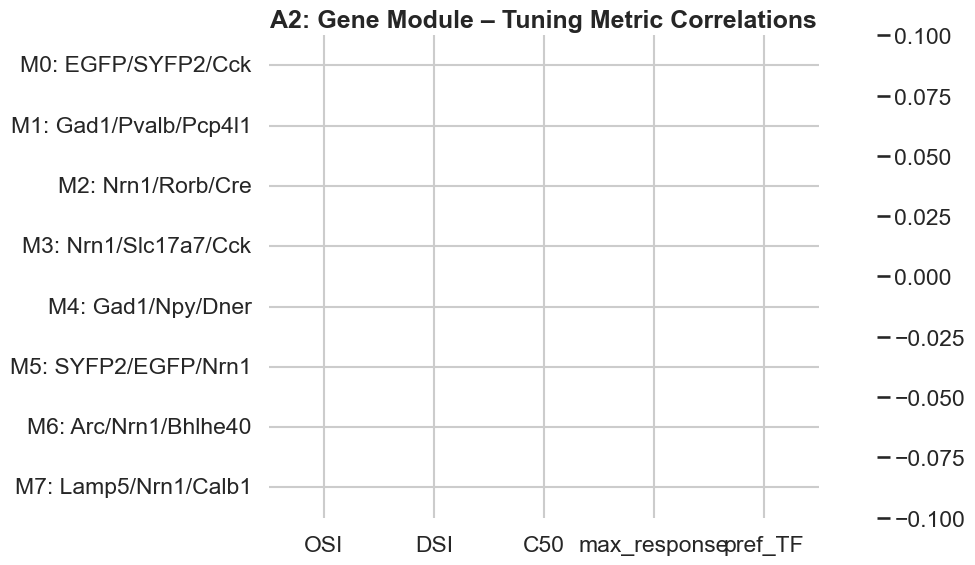

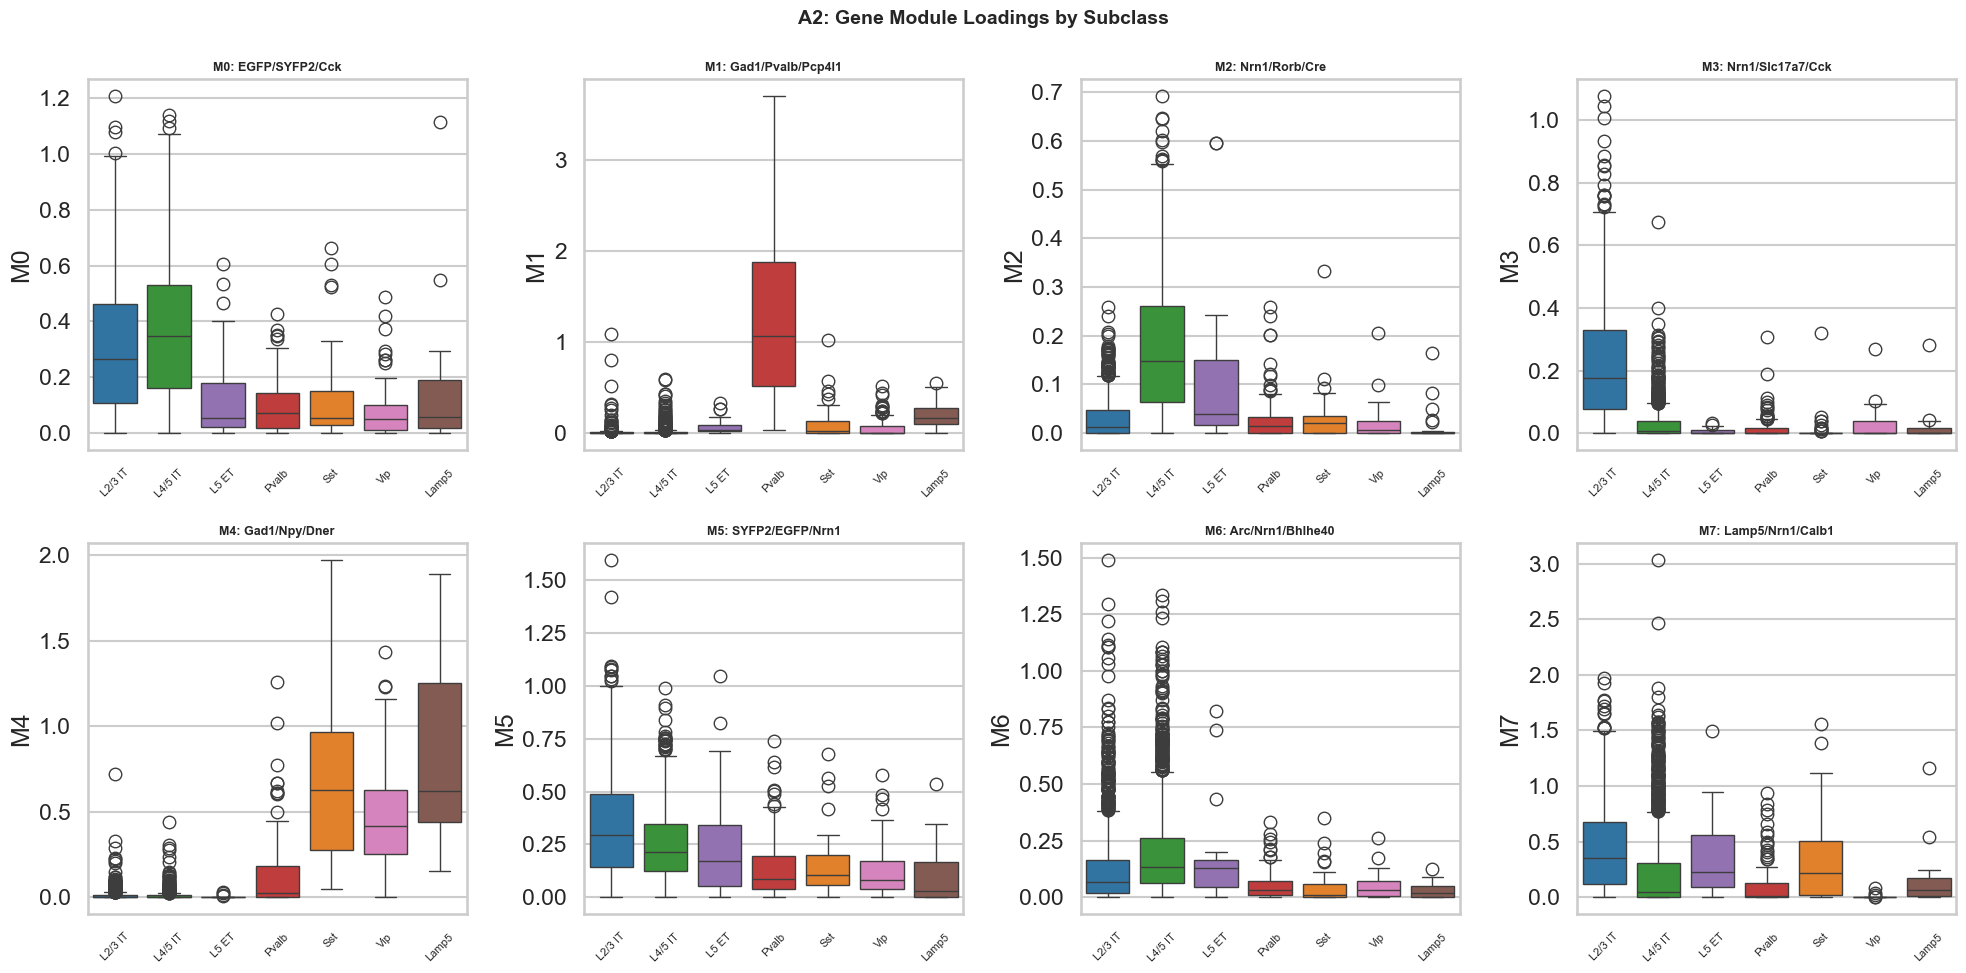

In [58]:
# ══════════════════════════════════════════════════════════════════════
# A2.3  Gene co-expression modules (NMF) and their functional associations
# ══════════════════════════════════════════════════════════════════════

# NMF on gene expression matrix (non-negative)
gene_matrix_nn = np.maximum(gene_matrix_filt, 0)
n_modules = 8

nmf = NMF(n_components=n_modules, max_iter=500, random_state=42)
W = nmf.fit_transform(gene_matrix_nn)  # cells x modules
H = nmf.components_  # modules x genes

print(f"NMF decomposition: {W.shape[0]} cells × {n_modules} modules")

# Name modules by top genes
module_names = []
for m in range(n_modules):
    top_idx = np.argsort(H[m])[::-1][:5]
    top = [gene_names_filt[i] for i in top_idx]
    module_names.append(f"M{m}: {'/'.join(top[:3])}")
    print(f"  Module {m}: {', '.join(top)}")

# ── Correlate modules with tuning metrics ──
module_tuning_corr = pd.DataFrame(index=module_names, columns=target_metrics, dtype=float)
for m in range(n_modules):
    for met in target_metrics:
        y = tuning_df[met].values
        valid = ~np.isnan(y)
        rho, p = spearmanr(W[valid, m], y[valid])
        module_tuning_corr.iloc[m][met] = rho

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(module_tuning_corr.astype(float), cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('A2: Gene Module – Tuning Metric Correlations', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Module loading by subclass ──
module_by_subclass = pd.DataFrame(W, columns=[f'M{i}' for i in range(n_modules)])
module_by_subclass['subclass'] = obs['subclass_name'].values
module_by_subclass['subclass_short'] = module_by_subclass['subclass'].map(SUBCLASS_SHORT)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, m in zip(axes.flat, range(n_modules)):
    sns.boxplot(data=module_by_subclass, x='subclass_short', y=f'M{m}',
                order=[SUBCLASS_SHORT[s] for s in present_subclasses],
                palette={SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}, ax=ax)
    ax.set_title(module_names[m], fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.suptitle('A2: Gene Module Loadings by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

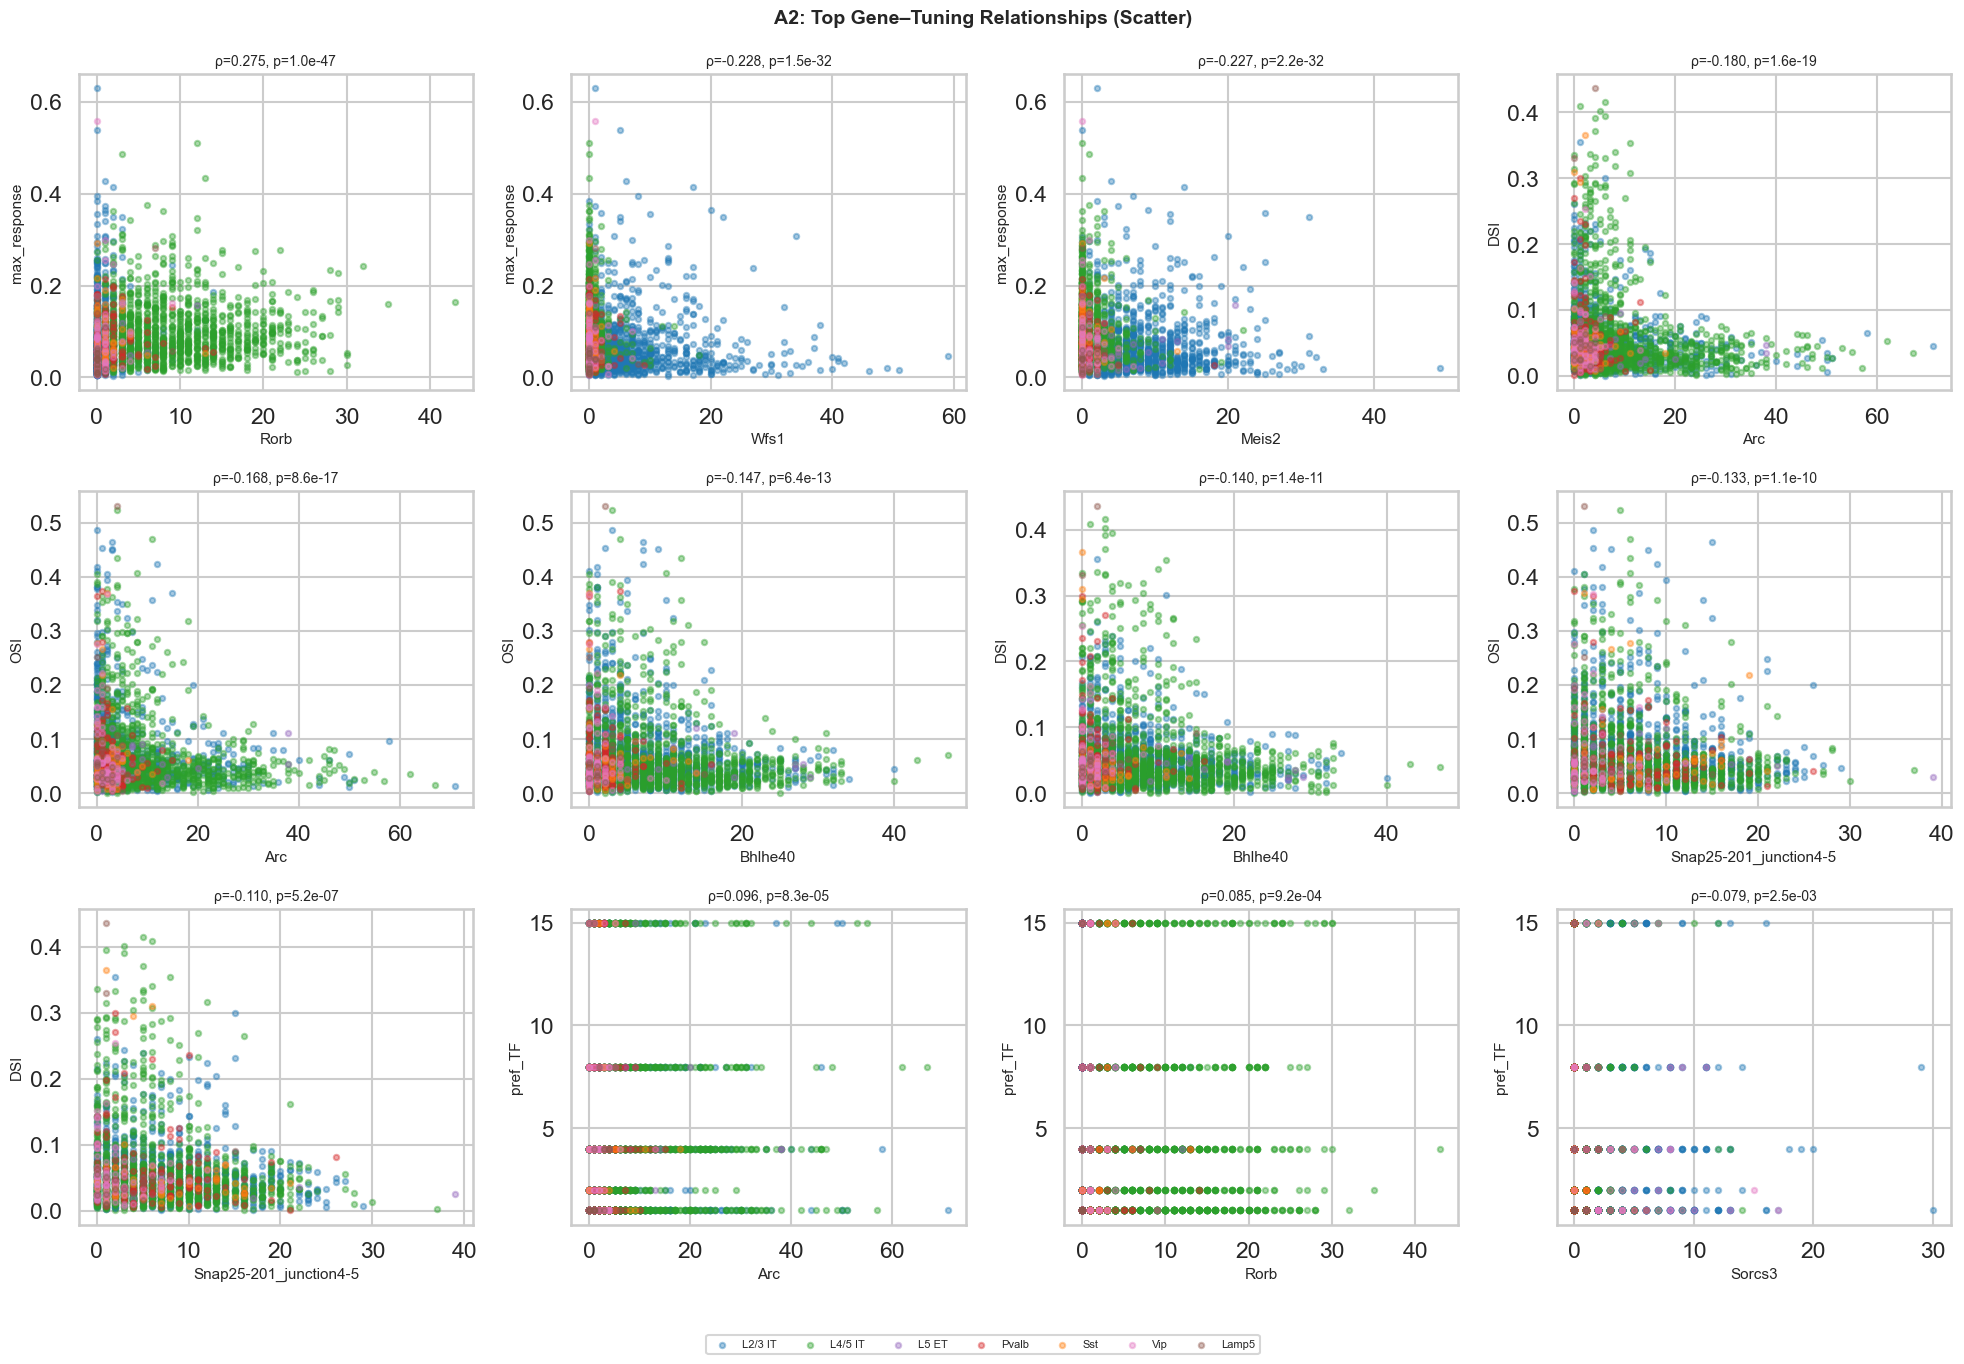

In [59]:
# ══════════════════════════════════════════════════════════════════════
# A2.4  Scatter plots for top gene–tuning relationships
# ══════════════════════════════════════════════════════════════════════

# Pick top 3 significant genes per metric (by absolute rho)
top_pairs = (corr_df[corr_df['sig']]
             .assign(abs_rho=lambda x: x['rho'].abs())
             .sort_values('abs_rho', ascending=False)
             .groupby('metric').head(3)
             .reset_index(drop=True))

n_pairs_plot = len(top_pairs)
if n_pairs_plot > 0:
    ncols = min(4, n_pairs_plot)
    nrows = int(np.ceil(n_pairs_plot / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flat

    for ax, (_, row) in zip(axes, top_pairs.iterrows()):
        gene, met = row['gene'], row['metric']
        gi = GENE_COLS.index(gene)
        gx = gene_expr[:, gi]
        y = tuning_df[met].values
        valid = ~np.isnan(y) & ~np.isnan(gx)
        sc_labels = obs['subclass_name'].values

        for sc in present_subclasses:
            m = valid & (sc_labels == sc)
            ax.scatter(gx[m], y[m], alpha=0.4, s=15, color=SUBCLASS_COLORS[sc],
                       label=SUBCLASS_SHORT[sc])
        ax.set_xlabel(gene, fontsize=11)
        ax.set_ylabel(met, fontsize=11)
        ax.set_title(f"ρ={row['rho']:.3f}, p={row['p_adj']:.1e}", fontsize=10)

    # Remove unused axes
    for ax in axes:
        if not ax.has_data():
            ax.set_visible(False)

    # Single legend outside
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(present_subclasses),
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle('A2: Top Gene–Tuning Relationships (Scatter)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
else:
    print("No significant gene–tuning pairs found.")

## A3: Population Coding Geometry

How does transcriptomic identity shape population-level stimulus representations? We examine:
- **A3.1** PCA / UMAP of population activity, colored by stimulus & cell type
- **A3.2** Representational Similarity Analysis (RSA) per subclass, with CKA comparison
- **A3.3** Stimulus decoding per subclass and mixed-population decoding

In [60]:
# ══════════════════════════════════════════════════════════════════════
# A3.1  PCA / UMAP of population activity colored by stimulus & cell type
# ══════════════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("⚠️ umap-learn not installed; falling back to t-SNE")

# ── Build trial-averaged stimulus response matrix ──
# Each row = one cell, each column = one stimulus condition (orientation × contrast in blocks 0,2)
# We use the contrast-context blocks for orientation × contrast conditions
var_cb = adata.var.copy()
block_mask = var_cb['stim_block'].isin([0.0, 2.0])

conditions = []
cond_labels = []
for ori in orientations:
    for c in contrasts:
        mask = block_mask & (var_cb['orientation'] == ori) & (var_cb['contrast'] == c)
        tidx = np.where(mask.values)[0]
        if len(tidx) > 0:
            conditions.append(np.nanmean(adata.X[:, tidx], axis=1))
            cond_labels.append(f"ori={int(ori)}°, c={c}")

stim_mat = np.column_stack(conditions)  # cells × conditions
print(f"Stimulus response matrix: {stim_mat.shape} (cells × conditions)")

# Z-score per cell for embedding
stim_z = (stim_mat - stim_mat.mean(axis=1, keepdims=True)) / (stim_mat.std(axis=1, keepdims=True) + 1e-8)
valid_cells_a3 = ~np.isnan(stim_z).any(axis=1)
stim_z_clean = stim_z[valid_cells_a3]
labels_a3 = obs['subclass_name'].values[valid_cells_a3]

# ── PCA ──
pca = PCA(n_components=10)
pcs = pca.fit_transform(stim_z_clean)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2, colored by cell type
ax = axes[0]
for sc in present_subclasses:
    m = labels_a3 == sc
    ax.scatter(pcs[m, 0], pcs[m, 1], alpha=0.4, s=12,
               color=SUBCLASS_COLORS[sc], label=SUBCLASS_SHORT[sc])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — by Cell Type', fontweight='bold')
ax.legend(fontsize=7, markerscale=2)

# Scree plot
ax = axes[1]
ax.bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue')
ax.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, 'ro-', markersize=5)
ax.set_xlabel('PC')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA Scree Plot', fontweight='bold')

# PC1 vs PC2, colored by preferred orientation
pref_ori_a3 = tuning_df['pref_ori'].values[valid_cells_a3]
ax = axes[2]
sc_ori = ax.scatter(pcs[:, 0], pcs[:, 1], c=pref_ori_a3, cmap='hsv',
                    alpha=0.4, s=12, vmin=0, vmax=180)
plt.colorbar(sc_ori, ax=ax, label='Pref. Orientation (°)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — by Preferred Orientation', fontweight='bold')

plt.suptitle('A3.1: Population Activity Embeddings', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── UMAP or t-SNE ──
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
    embed_2d = reducer.fit_transform(stim_z_clean)
    method_name = 'UMAP'
else:
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    embed_2d = tsne.fit_transform(stim_z_clean)
    method_name = 't-SNE'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for sc in present_subclasses:
    m = labels_a3 == sc
    ax.scatter(embed_2d[m, 0], embed_2d[m, 1], alpha=0.5, s=15,
               color=SUBCLASS_COLORS[sc], label=SUBCLASS_SHORT[sc])
ax.set_title(f'{method_name} — by Cell Type', fontweight='bold')
ax.legend(fontsize=7, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])

ax = axes[1]
sc_ori2 = ax.scatter(embed_2d[:, 0], embed_2d[:, 1], c=pref_ori_a3, cmap='hsv',
                     alpha=0.5, s=15, vmin=0, vmax=180)
plt.colorbar(sc_ori2, ax=ax, label='Pref. Orientation (°)')
ax.set_title(f'{method_name} — by Preferred Orientation', fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'A3.1: {method_name} Embedding of Population Responses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Stimulus response matrix: (1037, 40) (cells × conditions)


IndexError: Boolean index has wrong length: 1037 instead of 2824

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A3.2  Representational Similarity Analysis (RSA) per subclass + CKA
# ══════════════════════════════════════════════════════════════════════
from scipy.spatial.distance import squareform, pdist, correlation

def centered_kernel_alignment(X, Y):
    """CKA with linear kernel between two representations (samples × features)."""
    K = X @ X.T
    L = Y @ Y.T
    # Center kernels
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    Kc = H @ K @ H
    Lc = H @ L @ H
    hsic = np.sum(Kc * Lc)
    norm = np.sqrt(np.sum(Kc * Kc) * np.sum(Lc * Lc))
    return hsic / norm if norm > 0 else 0.0

# ── Build trial-averaged response per stimulus condition per subclass ──
# Stimulus conditions: each unique (orientation, contrast) pair in contrast-context blocks
n_conditions = len(cond_labels)

# For RSA we need the same conditions compared across subclasses
# RDM per subclass: pairwise distances between condition-averaged responses
rdms = {}
subclass_stim_mats = {}
for sc in present_subclasses:
    sc_mask = (obs['subclass_name'].values == sc) & valid_cells_a3
    if sc_mask.sum() < 5:
        continue
    # Mean response per condition across cells of this subclass
    sc_stim_vec = stim_mat[sc_mask]  # cells × conditions
    # RDM = pairwise correlation distance between conditions (using cell responses as features)
    rdm = squareform(pdist(sc_stim_vec.T, metric='correlation'))
    rdms[sc] = rdm
    subclass_stim_mats[sc] = sc_stim_vec

print(f"RDMs computed for {len(rdms)} subclasses, {n_conditions} conditions each")

# ── Visualize RDMs ──
n_rdm = len(rdms)
fig, axes = plt.subplots(1, n_rdm, figsize=(4.5 * n_rdm, 4))
if n_rdm == 1:
    axes = [axes]
for ax, sc in zip(axes, rdms):
    im = ax.imshow(rdms[sc], cmap='viridis', vmin=0, vmax=2)
    ax.set_title(SUBCLASS_SHORT[sc], fontweight='bold', color=SUBCLASS_COLORS[sc])
    ax.set_xlabel('Condition')
    ax.set_ylabel('Condition')
plt.suptitle('A3.2: Representational Dissimilarity Matrices (1 - corr)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes, shrink=0.7, label='Correlation Distance')
plt.tight_layout()
plt.show()

# ── CKA comparison between all pairs of subclasses ──
sc_list = list(subclass_stim_mats.keys())
n_sc = len(sc_list)

# We need matched conditions → use the condition-averaged response matrix
# Cell-averaged representation per subclass: conditions × 1 (mean across cells)
# Better: use the full cell × condition matrix, subsample to same size for CKA
min_cells = min(subclass_stim_mats[s].shape[0] for s in sc_list)
rng = np.random.default_rng(42)

cka_matrix = np.zeros((n_sc, n_sc))
n_repeats = 10
for i in range(n_sc):
    for j in range(n_sc):
        cka_vals = []
        for _ in range(n_repeats):
            Xi = subclass_stim_mats[sc_list[i]]
            Xj = subclass_stim_mats[sc_list[j]]
            # Subsample to min_cells for fair comparison
            idx_i = rng.choice(Xi.shape[0], size=min(min_cells, Xi.shape[0]), replace=False)
            idx_j = rng.choice(Xj.shape[0], size=min(min_cells, Xj.shape[0]), replace=False)
            # conditions × subsampled_cells
            cka_vals.append(centered_kernel_alignment(Xi[idx_i].T, Xj[idx_j].T))
        cka_matrix[i, j] = np.mean(cka_vals)

fig, ax = plt.subplots(figsize=(8, 6))
short_labels_cka = [SUBCLASS_SHORT[s] for s in sc_list]
sns.heatmap(cka_matrix, xticklabels=short_labels_cka, yticklabels=short_labels_cka,
            annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
ax.set_title('A3.2: CKA Similarity of Stimulus Representations Across Subclasses',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── RDM correlation matrix (second-order RSA) ──
rdm_vectors = {sc: squareform(rdms[sc]) for sc in sc_list}
rdm_corr = np.zeros((n_sc, n_sc))
for i in range(n_sc):
    for j in range(n_sc):
        rho, _ = spearmanr(rdm_vectors[sc_list[i]], rdm_vectors[sc_list[j]])
        rdm_corr[i, j] = rho

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rdm_corr, xticklabels=short_labels_cka, yticklabels=short_labels_cka,
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('A3.2: Second-Order RSA (Spearman ρ between RDMs)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A3.3  Stimulus decoding per subclass and mixed-population decoding
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── Prepare single-trial data for decoding ──
# Target: orientation (8 classes), using contrast-context blocks
var_dec = adata.var.copy()
block_dec_mask = var_dec['stim_block'].isin([0.0, 2.0]) & (~var_dec['gray_screen'].astype(bool))
trial_idx_dec = np.where(block_dec_mask.values)[0]

X_all_trials = adata.X[:, trial_idx_dec].T  # trials × cells
y_ori = var_dec.iloc[trial_idx_dec]['orientation'].values.astype(int)

# Remove trials with NaN
valid_trials = ~np.isnan(X_all_trials).any(axis=1)
X_all_trials = X_all_trials[valid_trials]
y_ori = y_ori[valid_trials]
print(f"Decoding data: {X_all_trials.shape[0]} trials × {X_all_trials.shape[1]} cells")
print(f"Orientation classes: {np.unique(y_ori)}")

sc_labels_all = obs['subclass_name'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Decode from each subclass separately ──
decode_results = {}
for sc in present_subclasses:
    sc_cell_idx = np.where(sc_labels_all == sc)[0]
    if len(sc_cell_idx) < 5:
        continue
    X_sc = X_all_trials[:, sc_cell_idx]

    accs = []
    for train_idx, test_idx in skf.split(X_sc, y_ori):
        scaler_d = StandardScaler()
        X_tr = scaler_d.fit_transform(X_sc[train_idx])
        X_te = scaler_d.transform(X_sc[test_idx])
        # LDA
        lda = LinearDiscriminantAnalysis()
        lda.fit(X_tr, y_ori[train_idx])
        accs.append(accuracy_score(y_ori[test_idx], lda.predict(X_te)))
    decode_results[sc] = {'lda_acc': np.mean(accs), 'lda_se': np.std(accs) / np.sqrt(len(accs)),
                          'n_cells': len(sc_cell_idx)}

# ── Decode from ALL cells combined ──
accs_all = []
for train_idx, test_idx in skf.split(X_all_trials, y_ori):
    scaler_d = StandardScaler()
    X_tr = scaler_d.fit_transform(X_all_trials[train_idx])
    X_te = scaler_d.transform(X_all_trials[test_idx])
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_tr, y_ori[train_idx])
    accs_all.append(accuracy_score(y_ori[test_idx], lda.predict(X_te)))
decode_results['All'] = {'lda_acc': np.mean(accs_all), 'lda_se': np.std(accs_all) / np.sqrt(len(accs_all)),
                         'n_cells': X_all_trials.shape[1]}

# ── Decode from excitatory only, then add each inhibitory subclass ──
exc_subclasses = [s for s in present_subclasses if 'Glut' in s]
inh_subclasses = [s for s in present_subclasses if 'Gaba' in s]
exc_cell_idx = np.where(np.isin(sc_labels_all, exc_subclasses))[0]

additive_results = {'Exc only': {'idx': exc_cell_idx}}
for inh_sc in inh_subclasses:
    inh_idx = np.where(sc_labels_all == inh_sc)[0]
    if len(inh_idx) < 3:
        continue
    combined_idx = np.concatenate([exc_cell_idx, inh_idx])
    additive_results[f'Exc + {SUBCLASS_SHORT[inh_sc]}'] = {'idx': combined_idx}

for label, info in additive_results.items():
    X_sub = X_all_trials[:, info['idx']]
    accs_sub = []
    for train_idx, test_idx in skf.split(X_sub, y_ori):
        scaler_d = StandardScaler()
        X_tr = scaler_d.fit_transform(X_sub[train_idx])
        X_te = scaler_d.transform(X_sub[test_idx])
        lda = LinearDiscriminantAnalysis()
        lda.fit(X_tr, y_ori[train_idx])
        accs_sub.append(accuracy_score(y_ori[test_idx], lda.predict(X_te)))
    additive_results[label]['acc'] = np.mean(accs_sub)
    additive_results[label]['se'] = np.std(accs_sub) / np.sqrt(len(accs_sub))

# ══════════════════════════════════════════════════════════════════════
# Visualization
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Decoding accuracy by subclass ──
ax = axes[0]
sc_names_dec = [SUBCLASS_SHORT.get(s, s) for s in decode_results]
accs_dec = [decode_results[s]['lda_acc'] for s in decode_results]
ses_dec = [decode_results[s]['lda_se'] for s in decode_results]
colors_dec = [SUBCLASS_COLORS.get(s, '#333333') for s in decode_results]
bars = ax.bar(sc_names_dec, accs_dec, yerr=ses_dec, capsize=4, color=colors_dec, edgecolor='black')
ax.axhline(1/8, ls='--', color='gray', alpha=0.5, label='Chance (1/8)')
ax.set_ylabel('Orientation Decoding Accuracy')
ax.set_title('Decoding per Subclass (LDA)', fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=45)
# Annotate n_cells
for bar, sc in zip(bars, decode_results):
    n = decode_results[sc]['n_cells']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={n}', ha='center', va='bottom', fontsize=8)

# ── Panel 2: Additive inhibitory contribution ──
ax = axes[1]
add_labels = list(additive_results.keys())
add_accs = [additive_results[k]['acc'] for k in add_labels]
add_ses = [additive_results[k]['se'] for k in add_labels]
ax.barh(add_labels, add_accs, xerr=add_ses, capsize=4, color='steelblue', edgecolor='black')
ax.axvline(1/8, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Decoding Accuracy')
ax.set_title('Excitatory + Inhibitory Subclass', fontweight='bold')

# ── Panel 3: Decoding as function of population size ──
ax = axes[2]
# Subsample cells at different population sizes
pop_sizes = [10, 25, 50, 100, 200, 500, min(1000, X_all_trials.shape[1])]
pop_sizes = [p for p in pop_sizes if p <= X_all_trials.shape[1]]
pop_accs = []
pop_ses_list = []
rng_dec = np.random.default_rng(42)
for ps in pop_sizes:
    rep_accs = []
    for rep in range(5):
        cell_subset = rng_dec.choice(X_all_trials.shape[1], size=ps, replace=False)
        X_sub_ps = X_all_trials[:, cell_subset]
        fold_accs = []
        for train_idx, test_idx in skf.split(X_sub_ps, y_ori):
            scaler_d = StandardScaler()
            X_tr = scaler_d.fit_transform(X_sub_ps[train_idx])
            X_te = scaler_d.transform(X_sub_ps[test_idx])
            lda = LinearDiscriminantAnalysis()
            lda.fit(X_tr, y_ori[train_idx])
            fold_accs.append(accuracy_score(y_ori[test_idx], lda.predict(X_te)))
        rep_accs.append(np.mean(fold_accs))
    pop_accs.append(np.mean(rep_accs))
    pop_ses_list.append(np.std(rep_accs) / np.sqrt(len(rep_accs)))

ax.errorbar(pop_sizes, pop_accs, yerr=pop_ses_list, marker='o', linewidth=2,
            capsize=4, color='darkblue')
ax.axhline(1/8, ls='--', color='gray', alpha=0.5, label='Chance')
ax.set_xlabel('Population Size (# cells)')
ax.set_ylabel('Decoding Accuracy')
ax.set_title('Decoding vs Population Size', fontweight='bold')
ax.set_xscale('log')
ax.legend()

plt.suptitle('A3.3: Stimulus Decoding Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## A4: Cell-Type Temporal Dynamics (10 Hz ΔF/F)

Using trial-resolved 10 Hz ΔF/F traces from zarr stores (-1 s to +3 s around stimulus onset), we characterize:
- **A4.1** PSTHs by subclass — onset latency, peak timing, transient vs sustained index
- **A4.2** Temporal diversity within and across subclasses

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A4.1  Load 10 Hz data & compute PSTHs by subclass
# ══════════════════════════════════════════════════════════════════════

def load_zarr_10hz(mouse_id, session='session_1'):
    """Load 10 Hz trial-resolved data from zarr."""
    z = zarr.open(f'{ZARR_DIR}/{mouse_id}_multimodal_data.zarr', 'r')
    gs = z[f'ophys/drifting_gratings/{session}/stim_aligned_dff/GratingStim']
    ti_dict = {k: gs[f'trial_info/{k}'][:] for k in gs['trial_info'].keys()}
    return {
        'dff': gs['dff'][:],
        'unique_ids': z['unique_id'][:].astype(str),
        'running': gs['running'][:],
        'time_rel': gs['time_relative'][:],
        'trial_info': pd.DataFrame(ti_dict),
    }

# Load session 1 from all mice, match cells to obs
all_psth = []       # will be (n_cells_matched, 41) mean PSTH
all_subclass = []
all_mouse = []
all_dff_trials = [] # (n_cells_matched,) each entry: (n_gratings, 41) non-gray trials

for mouse_id in MOUSE_IDS:
    pk = load_zarr_10hz(mouse_id)
    dff = pk['dff']            # (n_trials, 41, n_cells)
    ti = pk['trial_info']
    time_rel = pk['time_rel']
    uids = pk['unique_ids']
    
    # Select non-gray-screen grating trials
    grating_mask = ~ti['gray_screen'].astype(bool)
    dff_grating = dff[grating_mask.values]  # (n_grating_trials, 41, n_cells)
    
    # Match cells to obs (by unique_id)
    obs_mouse = obs[obs['mouse_id'] == mouse_id]
    for ci, uid in enumerate(uids):
        if uid in obs_mouse['unique_id'].values:
            row = obs_mouse[obs_mouse['unique_id'] == uid].iloc[0]
            psth = np.nanmean(dff_grating[:, :, ci], axis=0)  # mean across all grating trials
            all_psth.append(psth)
            all_subclass.append(row['subclass_name'])
            all_mouse.append(mouse_id)
            all_dff_trials.append(dff_grating[:, :, ci])  # (n_grating_trials, 41)

all_psth = np.array(all_psth)          # (n_cells_matched, 41)
all_subclass = np.array(all_subclass)
print(f"Matched {len(all_psth)} cells with 10 Hz temporal data")
print(f"Time points: {len(time_rel)}, from {time_rel[0]:.1f}s to {time_rel[-1]:.1f}s")

# ── Compute temporal metrics ──
stim_on_idx = np.argmin(np.abs(time_rel))  # t=0
baseline_idx = time_rel < 0                 # pre-stimulus
stim_idx = (time_rel >= 0) & (time_rel <= 2.0)
early_idx = (time_rel >= 0) & (time_rel <= 0.5)
late_idx = (time_rel >= 1.5) & (time_rel <= 2.0)

baseline_mean = np.nanmean(all_psth[:, baseline_idx], axis=1)
peak_response = np.nanmax(all_psth[:, stim_idx], axis=1)
early_response = np.nanmean(all_psth[:, early_idx], axis=1)
late_response = np.nanmean(all_psth[:, late_idx], axis=1)

# Transient/Sustained index: (early - late) / (early + late)
tsi = (early_response - late_response) / (np.abs(early_response) + np.abs(late_response) + 1e-8)

# Onset latency: first time point after stim onset where PSTH > baseline + 2*SD(baseline)
baseline_std = np.nanstd(all_psth[:, baseline_idx], axis=1)
onset_latency = np.full(len(all_psth), np.nan)
for ci in range(len(all_psth)):
    threshold = baseline_mean[ci] + 2 * baseline_std[ci]
    above = np.where((time_rel >= 0) & (all_psth[ci] > threshold))[0]
    if len(above) > 0:
        onset_latency[ci] = time_rel[above[0]]

# Peak time
peak_time = np.array([time_rel[stim_idx][np.argmax(all_psth[ci, stim_idx])] for ci in range(len(all_psth))])

temporal_df = pd.DataFrame({
    'subclass': all_subclass,
    'mouse': all_mouse,
    'tsi': tsi,
    'onset_latency': onset_latency,
    'peak_time': peak_time,
    'peak_response': peak_response,
    'baseline': baseline_mean,
    'subclass_short': [SUBCLASS_SHORT.get(s, s) for s in all_subclass],
})

# ══════════════════════════════════════════════════════════════════════
# Visualization: PSTHs by subclass + temporal metrics
# ══════════════════════════════════════════════════════════════════════
present_sc_temp = [s for s in SUBCLASS_ORDER if s in all_subclass]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# ── Row 1: PSTHs per subclass ──
for ax, sc in zip(axes[0], present_sc_temp):
    mask = all_subclass == sc
    mean_p = np.nanmean(all_psth[mask], axis=0)
    sem_p = np.nanstd(all_psth[mask], axis=0) / np.sqrt(mask.sum())
    ax.fill_between(time_rel, mean_p - sem_p, mean_p + sem_p,
                    alpha=0.3, color=SUBCLASS_COLORS[sc])
    ax.plot(time_rel, mean_p, color=SUBCLASS_COLORS[sc], linewidth=2)
    ax.axvline(0, color='k', ls='--', alpha=0.4, label='Stim ON')
    ax.axvline(2.0, color='k', ls=':', alpha=0.4, label='Stim OFF')
    ax.set_title(f'{SUBCLASS_SHORT[sc]} (n={mask.sum()})',
                 color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('Time (s)')
if len(present_sc_temp) < 4:
    for ax in axes[0, len(present_sc_temp):]:
        ax.set_visible(False)
axes[0, 0].set_ylabel('ΔF/F')

# ── Overlaid PSTHs ──
ax = axes[0, -1] if len(present_sc_temp) >= 4 else axes[0, len(present_sc_temp)]
for sc in present_sc_temp:
    mask = all_subclass == sc
    mean_p = np.nanmean(all_psth[mask], axis=0)
    ax.plot(time_rel, mean_p, color=SUBCLASS_COLORS[sc], linewidth=2,
            label=SUBCLASS_SHORT[sc])
ax.axvline(0, color='k', ls='--', alpha=0.4)
ax.axvline(2.0, color='k', ls=':', alpha=0.4)
ax.legend(fontsize=7)
ax.set_title('All Subclasses Overlaid', fontweight='bold')
ax.set_xlabel('Time (s)')
ax.set_ylabel('ΔF/F')

# ── Row 2: Temporal metric distributions ──
short_order = [SUBCLASS_SHORT[s] for s in present_sc_temp]
short_pal = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}

for ax, met, lab in zip(axes[1], ['tsi', 'onset_latency', 'peak_time', 'peak_response'],
                        ['Transient-Sustained Index', 'Onset Latency (s)',
                         'Peak Time (s)', 'Peak ΔF/F']):
    sns.violinplot(data=temporal_df, x='subclass_short', y=met,
                   order=short_order, palette=short_pal, cut=0, inner='box', ax=ax)
    ax.set_title(lab, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('A4: Cell-Type Temporal Dynamics (10 Hz PSTH)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Stats ──
from scipy.stats import kruskal
print("\n=== Kruskal-Wallis across subclasses ===")
for met in ['tsi', 'onset_latency', 'peak_time', 'peak_response']:
    groups = [temporal_df.loc[temporal_df['subclass'] == s, met].dropna() for s in present_sc_temp]
    groups = [g.values for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"  {met:20s}: H={stat:.2f}, p={p:.2e}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A4.2  Temporal diversity: how variable are temporal profiles within
#       and across subclasses? Do genes predict temporal dynamics?
# ══════════════════════════════════════════════════════════════════════
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# ── Normalize each cell's PSTH for shape comparison (unit norm on stim period) ──
stim_psth = all_psth[:, stim_idx]  # (n_cells, stim_timepoints)
stim_psth_norm = stim_psth / (np.linalg.norm(stim_psth, axis=1, keepdims=True) + 1e-8)

# ── Cluster cells by temporal shape ──
n_clust = 5
D = pdist(stim_psth_norm, metric='correlation')
Z = linkage(D, method='ward')
clust_labels = fcluster(Z, n_clust, criterion='maxclust')

# ── Mean temporal profile per cluster ──
fig, axes = plt.subplots(1, n_clust + 1, figsize=(4 * (n_clust + 1), 4), sharey=True)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, n_clust))

for ci in range(1, n_clust + 1):
    ax = axes[ci - 1]
    cmask = clust_labels == ci
    mean_p = np.nanmean(stim_psth[cmask], axis=0)
    sem_p = np.nanstd(stim_psth[cmask], axis=0) / np.sqrt(cmask.sum())
    t_stim = time_rel[stim_idx]
    ax.fill_between(t_stim, mean_p - sem_p, mean_p + sem_p,
                    alpha=0.3, color=cluster_colors[ci - 1])
    ax.plot(t_stim, mean_p, color=cluster_colors[ci - 1], linewidth=2)
    ax.set_title(f'Cluster {ci} (n={cmask.sum()})', fontweight='bold')
    ax.set_xlabel('Time (s)')
axes[0].set_ylabel('ΔF/F')

# Subclass composition per cluster (stacked bar)
ax = axes[-1]
comp = pd.DataFrame({'cluster': clust_labels, 'subclass': all_subclass})
ct = pd.crosstab(comp['cluster'], comp['subclass'], normalize='index')
ct_short = ct.rename(columns=SUBCLASS_SHORT)
ct_short[[SUBCLASS_SHORT[s] for s in present_sc_temp if SUBCLASS_SHORT[s] in ct_short.columns]].plot(
    kind='bar', stacked=True, ax=ax,
    color=[SUBCLASS_COLORS[s] for s in present_sc_temp if SUBCLASS_SHORT[s] in ct_short.columns])
ax.set_title('Subclass Composition', fontweight='bold')
ax.set_xlabel('Temporal Cluster')
ax.set_ylabel('Fraction')
ax.legend(fontsize=7, loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('A4: Temporal Response Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Within-subclass temporal diversity (mean pairwise correlation distance) ──
diversity = {}
for sc in present_sc_temp:
    sc_mask = all_subclass == sc
    if sc_mask.sum() < 5:
        continue
    D_sc = pdist(stim_psth_norm[sc_mask], metric='correlation')
    diversity[SUBCLASS_SHORT[sc]] = np.mean(D_sc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(diversity.keys(), diversity.values(),
       color=[SUBCLASS_COLORS[s] for s in present_sc_temp if SUBCLASS_SHORT[s] in diversity])
ax.set_ylabel('Mean Correlation Distance')
ax.set_title('A4: Within-Subclass Temporal Diversity', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Do temporal metrics correlate with genes? Quick LASSO screen ──
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Match cells back to obs to get gene expression
temporal_df['unique_id'] = None  # placeholder — we'll use index matching
# Use the gene matrix from the full obs (already loaded in A2)
# We need to match all_subclass ordering to obs

# Use mouse_id + subclass to re-index into obs gene columns
# For simplicity, use the temporal metrics and try predicting from tuning_df metrics
print("\n=== Temporal metric correlations with tuning metrics ===")
# Quick check: correlate TSI with OSI, C50, etc. using matched cells
# (This is a coarse match since cell ordering may differ)
print(f"TSI mean by subclass:")
for sc in present_sc_temp:
    vals = temporal_df.loc[temporal_df['subclass'] == sc, 'tsi'].dropna()
    print(f"  {SUBCLASS_SHORT[sc]:10s}: {vals.mean():.3f} ± {vals.std():.3f} (n={len(vals)})")